#I.Business Understanding

##1.Xác định business problem, mục tiêu dự án, ML problem, target và success criteria

#II.Data Understanding

##2.Tổng quan dataset: số dòng/cột, datatype, numerical/categorical/binary, missing, unknown, duplicate

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from scipy.io import arff
import os

# THAY ĐỔI ĐƯỜNG DẪN NÀY
file_path = '/content/drive/MyDrive/phpkIxskf.arff'

if os.path.exists(file_path):
    try:
        data, meta = arff.loadarff(file_path)
        df = pd.DataFrame(data)

        # Decode bytes strings if necessary
        for column in df.select_dtypes(include=['object']).columns:
            if df[column].apply(lambda x: isinstance(x, bytes)).any():
                df[column] = df[column].str.decode('utf-8')

        # Mapping columns to English names
        column_mapping = {
            'V1': 'age',
            'V2': 'job',
            'V3': 'marital',
            'V4': 'education',
            'V5': 'default',
            'V6': 'balance',
            'V7': 'housing',
            'V8': 'loan',
            'V9': 'contact',
            'V10': 'day',
            'V11': 'month',
            'V12': 'duration',
            'V13': 'campaign',
            'V14': 'pdays',
            'V15': 'previous',
            'V16': 'poutcome',
            'Class': 'y'
        }

        df = df.rename(columns=column_mapping)
        print("Columns renamed successfully!")
        display(df.head())

        # Save to CSV
        csv_output = 'converted_data.csv'
        df.to_csv(csv_output, index=False)
        print(f"CSV file saved at: {csv_output}")

    except Exception as e:
        print(f"Error reading file: {e}")
else:
    print("File not found. Please check the path again.")

Columns renamed successfully!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,may,261.0,1.0,-1.0,0.0,unknown,1
1,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5.0,may,151.0,1.0,-1.0,0.0,unknown,1
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5.0,may,76.0,1.0,-1.0,0.0,unknown,1
3,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5.0,may,92.0,1.0,-1.0,0.0,unknown,1
4,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5.0,may,198.0,1.0,-1.0,0.0,unknown,1


CSV file saved at: converted_data.csv


In [ ]:
print("--- 5 dòng đầu tiên ---")
display(df.head(5))

print("\n--- 5 dòng cuối cùng ---")
display(df.tail(5))

print("\n--- 5 dòng ngẫu nhiên ---")
display(df.sample(5))

--- 5 dòng đầu tiên ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,may,261.0,1.0,-1.0,0.0,unknown,1
1,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5.0,may,151.0,1.0,-1.0,0.0,unknown,1
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5.0,may,76.0,1.0,-1.0,0.0,unknown,1
3,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5.0,may,92.0,1.0,-1.0,0.0,unknown,1
4,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5.0,may,198.0,1.0,-1.0,0.0,unknown,1



--- 5 dòng cuối cùng ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51.0,technician,married,tertiary,no,825.0,no,no,cellular,17.0,nov,977.0,3.0,-1.0,0.0,unknown,2
45207,71.0,retired,divorced,primary,no,1729.0,no,no,cellular,17.0,nov,456.0,2.0,-1.0,0.0,unknown,2
45208,72.0,retired,married,secondary,no,5715.0,no,no,cellular,17.0,nov,1127.0,5.0,184.0,3.0,success,2
45209,57.0,blue-collar,married,secondary,no,668.0,no,no,telephone,17.0,nov,508.0,4.0,-1.0,0.0,unknown,1
45210,37.0,entrepreneur,married,secondary,no,2971.0,no,no,cellular,17.0,nov,361.0,2.0,188.0,11.0,other,1



--- 5 dòng ngẫu nhiên ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
37481,38.0,technician,single,tertiary,no,69.0,yes,no,cellular,13.0,may,253.0,3.0,-1.0,0.0,unknown,1
21012,57.0,retired,married,secondary,no,191.0,no,no,cellular,14.0,aug,127.0,4.0,-1.0,0.0,unknown,1
42428,42.0,management,married,tertiary,no,144.0,no,no,cellular,7.0,dec,143.0,1.0,283.0,3.0,failure,1
43257,44.0,management,married,unknown,no,282.0,no,no,cellular,9.0,mar,700.0,2.0,154.0,3.0,success,2
27696,32.0,technician,single,tertiary,no,785.0,yes,no,cellular,21.0,nov,53.0,2.0,-1.0,0.0,unknown,1


1 age: Tuổi của khách hàng

2	job	: Loại công việc/nghề nghiệp của khách hàng

3	marital:	Tình trạng hôn nhân của khách hàng

4	education:	Trình độ học vấn của khách hàng

5	default:	Cho biết khách hàng có tín dụng bị vỡ nợ hay không

6	balance:	Số dư trung bình hàng năm trong tài khoản của khách hàng, tính bằng Euro

7	housing:	Cho biết khách hàng có khoản vay mua nhà hay không

8	loan:	Cho biết khách hàng có khoản vay cá nhân hay không

9	contact:	Loại hình liên lạc được sử dụng trong lần liên hệ gần nhất của chiến dịch hiện tại

10	day	:Ngày trong tháng của lần liên hệ gần nhất

11	month:	Tháng trong năm của lần liên hệ gần nhất

12	duration:	Thời lượng của lần liên hệ cuối cùng, tính bằng giây

13	campaign:	Số lần liên hệ đã thực hiện với khách hàng trong chiến dịch hiện tại, bao gồm cả lần liên hệ cuối cùng

14	pdays:	Số ngày kể từ lần cuối khách hàng được liên hệ trong một chiến dịch trước đó; -1 nghĩa là chưa từng được liên hệ trước đó

15	previous:	Số lần khách hàng đã được liên hệ trước chiến dịch hiện tại

16	poutcome:	Kết quả của chiến dịch marketing trước đó

17	y	:Cho biết khách hàng có đăng ký tiền gửi có kỳ hạn hay không

In [ ]:
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")

print("\n--- Thông tin kiểu dữ liệu ---")
display(df.info())


print("\n--- Kiểm tra các giá trị 'unknown' trong các cột categorical ---")
for col in df.select_dtypes(include=['object']).columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} giá trị 'unknown'")

print("\n--- Kiểm tra dòng bị lặp (Duplicates) ---")
duplicates = df.duplicated().sum()
print(f"Số dòng bị lặp: {duplicates}")

Số dòng: 45211
Số cột: 17

--- Thông tin kiểu dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  object 
 2   marital    45211 non-null  object 
 3   education  45211 non-null  object 
 4   default    45211 non-null  object 
 5   balance    45211 non-null  float64
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   contact    45211 non-null  object 
 9   day        45211 non-null  float64
 10  month      45211 non-null  object 
 11  duration   45211 non-null  float64
 12  campaign   45211 non-null  float64
 13  pdays      45211 non-null  float64
 14  previous   45211 non-null  float64
 15  poutcome   45211 non-null  object 
 16  y          45211 non-null  object 
dtypes: float64(7), object(10)
memory usage: 5.9+ MB


None


--- Kiểm tra các giá trị 'unknown' trong các cột categorical ---
job: 288 giá trị 'unknown'
education: 1857 giá trị 'unknown'
contact: 13020 giá trị 'unknown'
poutcome: 36959 giá trị 'unknown'

--- Kiểm tra dòng bị lặp (Duplicates) ---
Số dòng bị lặp: 0


insight:có 7 giá trị đinh lượng 9 giá trị định tính

có 4 biến job ,education,contact,poutcome có giá trị unknown nhiều

không có giá trị nào trùng lặp thì có thể thấy dữ liệu trên nhiều đối tượng

---



In [ ]:
print("--- Thống kê mô tả cho các biến số (Numerical) ---")
display(df.describe())

print("\n--- Thống kê mô tả cho các biến phân loại (Categorical) ---")
display(df.describe(include=['object']))

--- Thống kê mô tả cho các biến số (Numerical) ---


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



--- Thống kê mô tả cho các biến phân loại (Categorical) ---


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,1
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


insight:các biến định lượng thấy được sự phân bố tương đối của từng biến

các biến định tính thấy được số lượng các giá trị của từng biến và sự phân bố các biến định lượng

## 3.Univariate EDA: Phân tích đơn biến


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set(style="whitegrid")

# Lấy danh sách các cột số và cột phân loại
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Các cột định lượng: {list(num_cols)}")
print(f"Các cột định tính: {list(cat_cols)}")

Các cột định lượng: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Các cột định tính: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


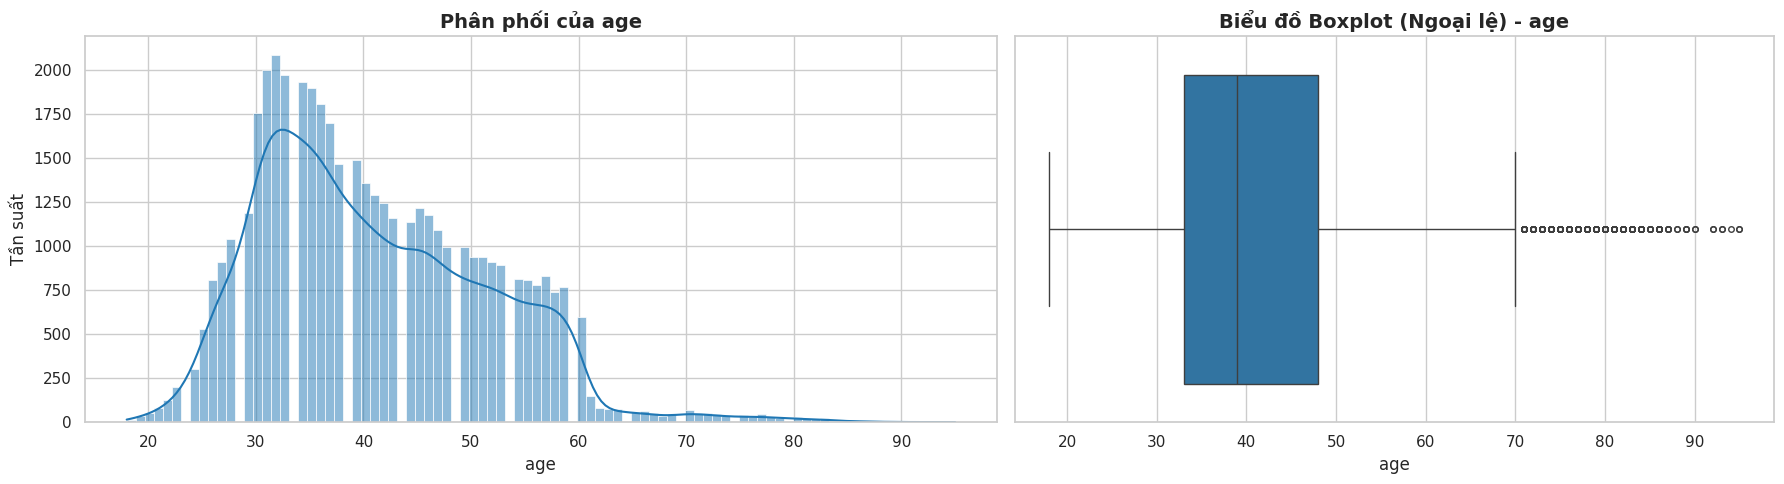

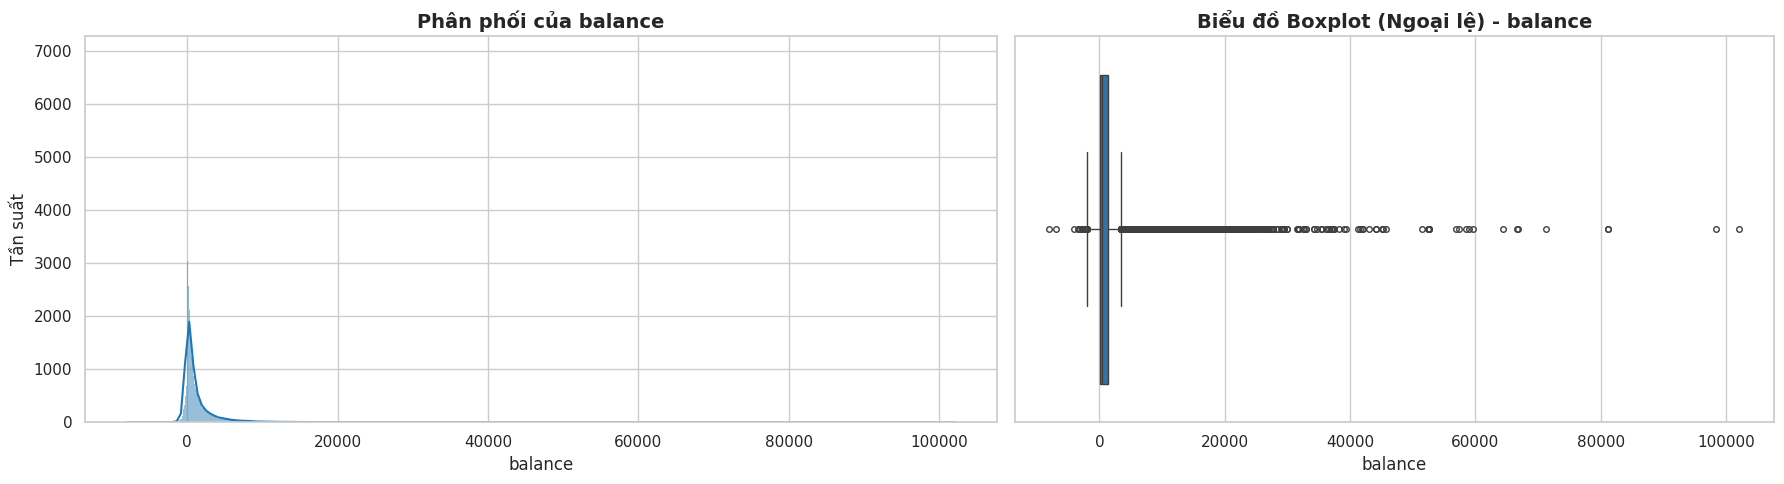

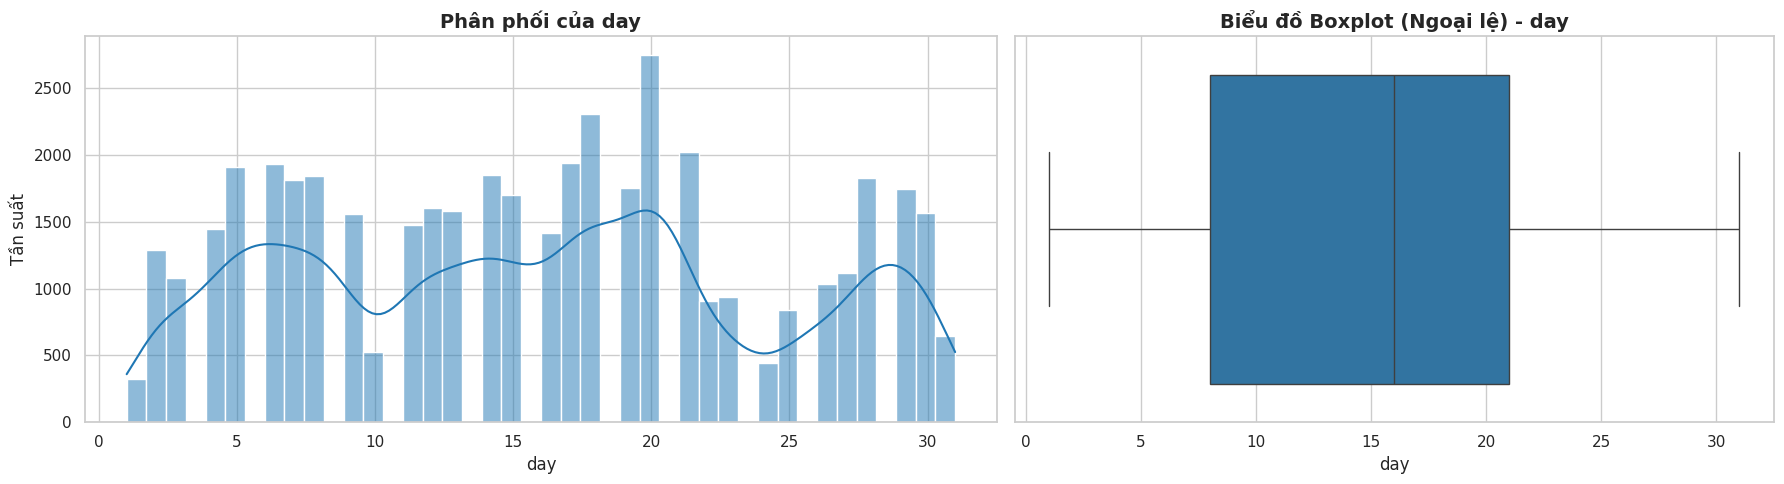

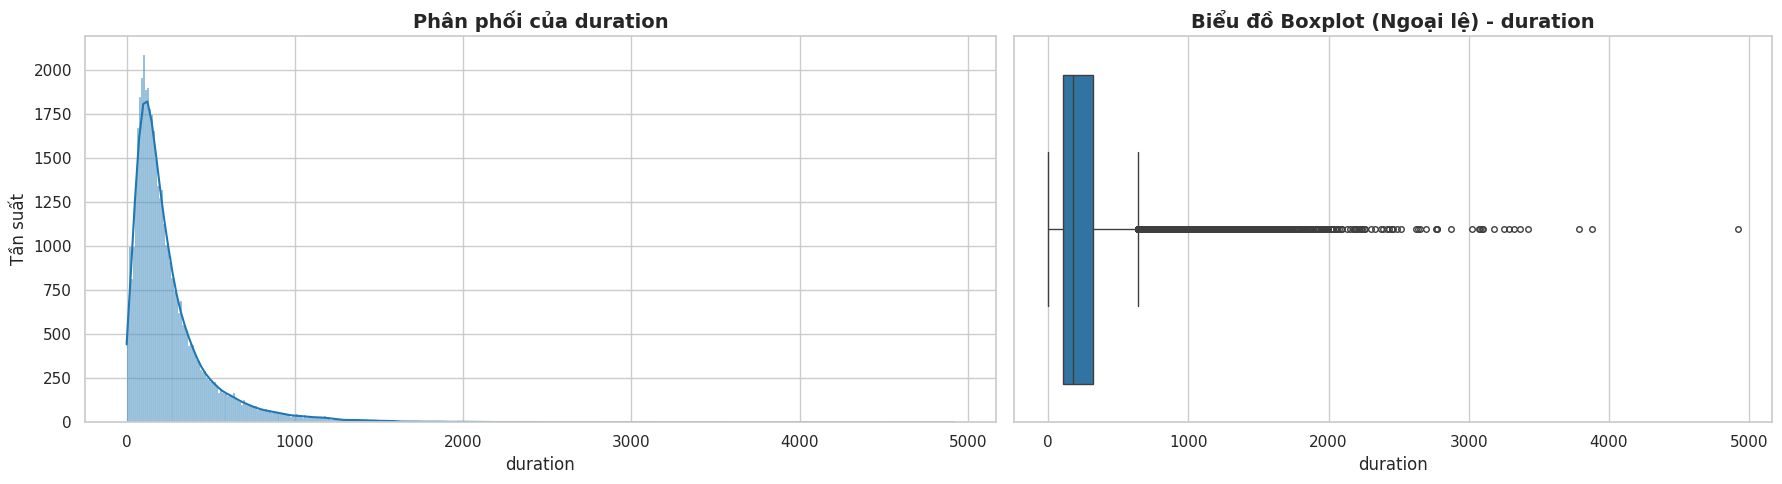

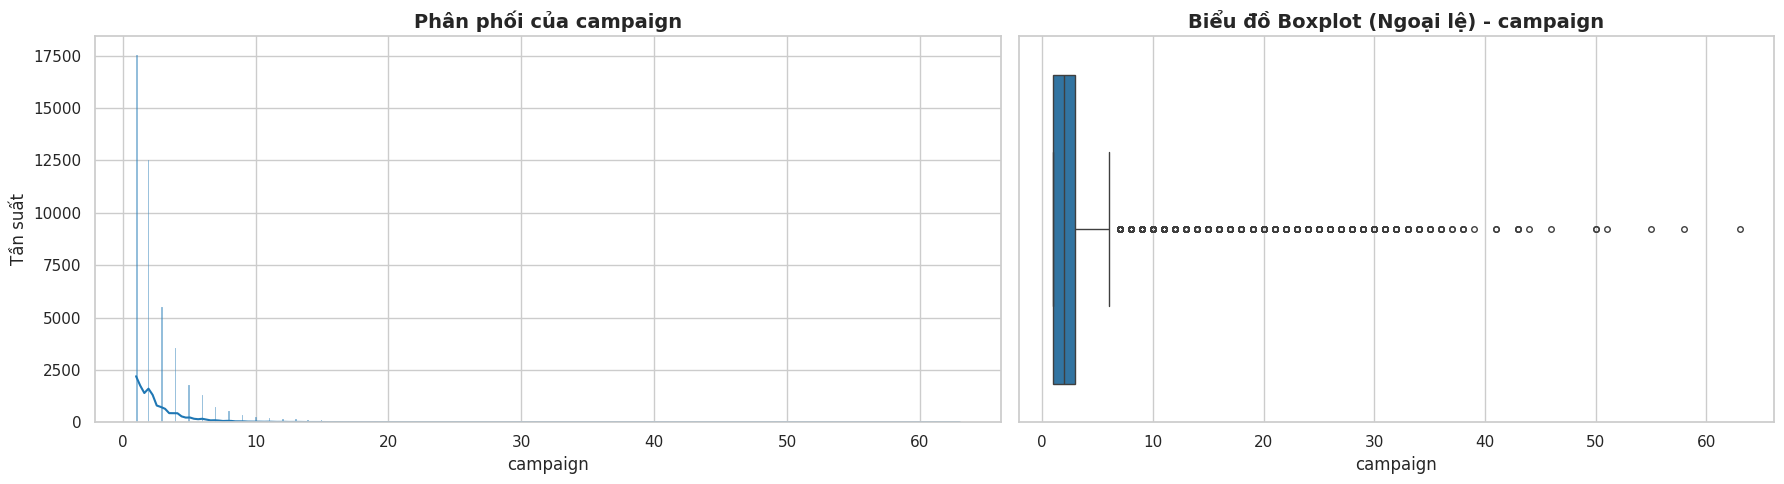

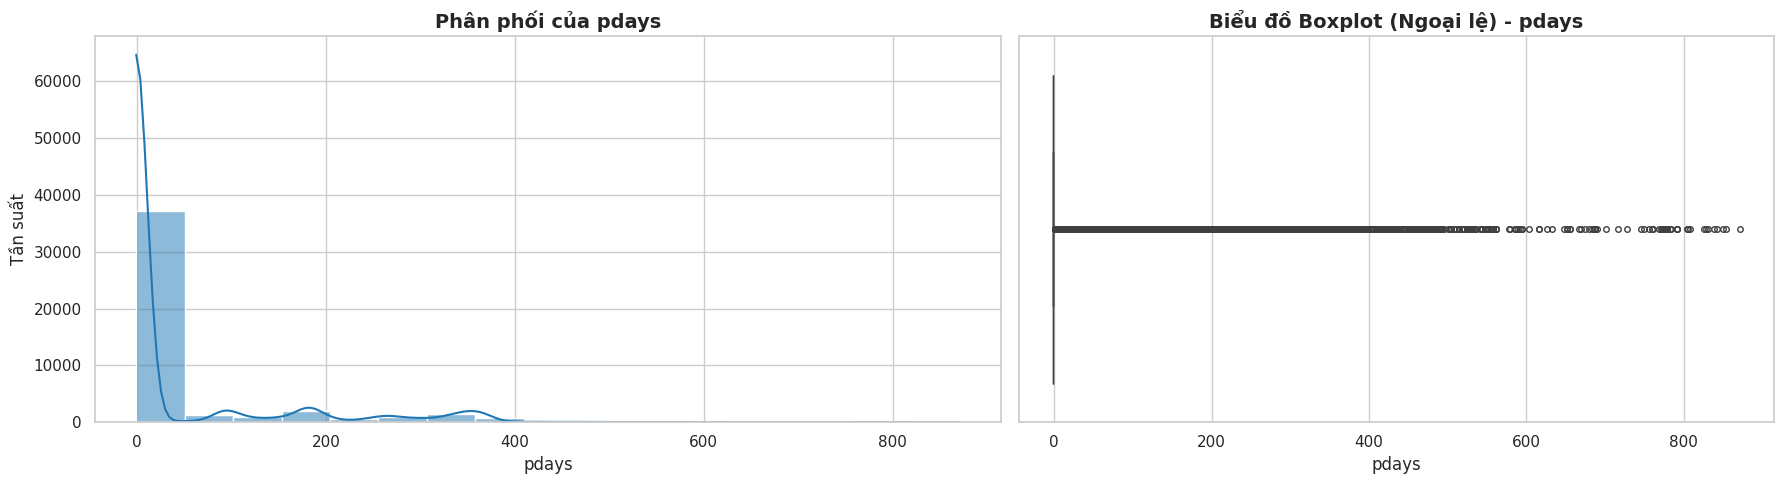

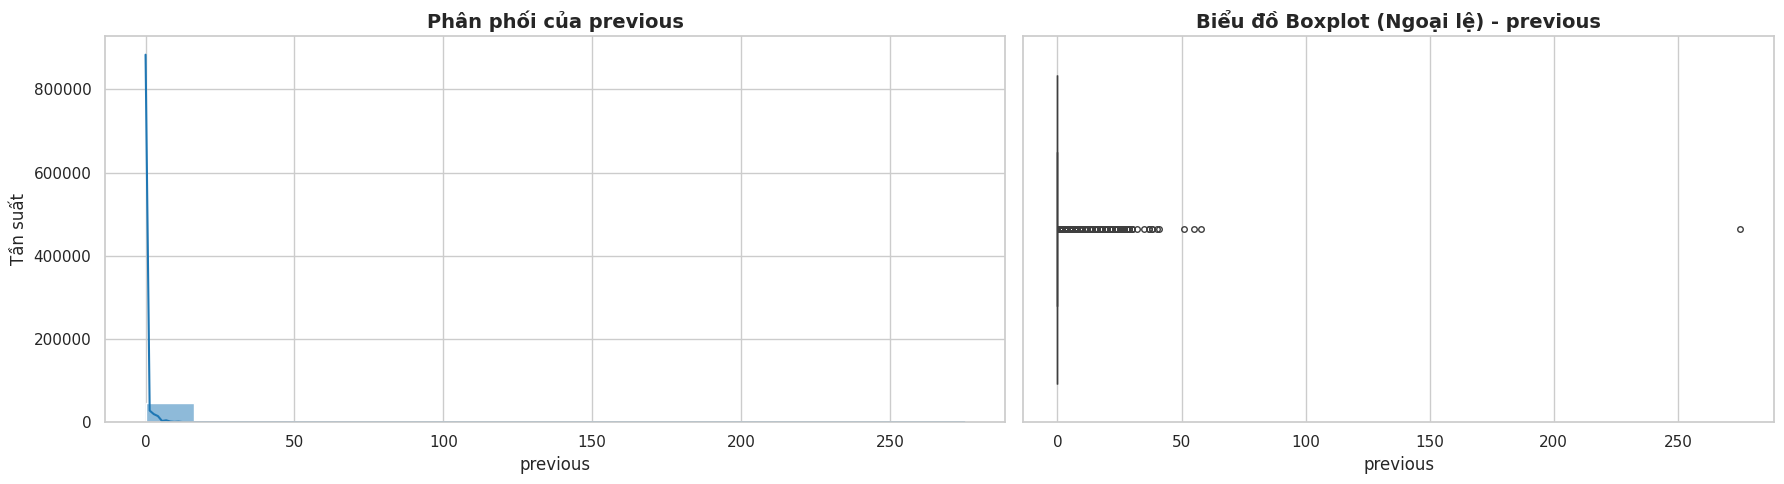

In [ ]:
# 3.1 Trực quan hóa biến định lượng (Numerical) với Boxplot xoay ngang và màu xanh
for col in num_cols:
    # Mở rộng chiều ngang figsize=(18, 5) để boxplot dễ nhìn hơn
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [1.2, 1]})

    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[0], color='#1f77b4', edgecolor='white')
    axes[0].set_title(f'Phân phối của {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(col, fontsize=12)
    axes[0].set_ylabel('Tần suất', fontsize=12)

    # Boxplot xoay ngang (x=col) và đổi sang màu xanh (#1f77b4)
    sns.boxplot(x=df[col], ax=axes[1], color='#1f77b4', fliersize=4)
    axes[1].set_title(f'Biểu đồ Boxplot (Ngoại lệ) - {col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=12)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


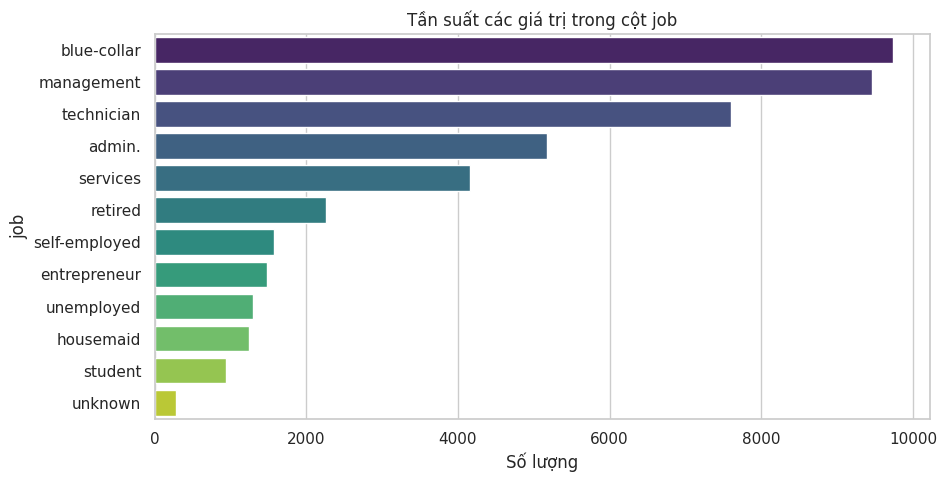

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


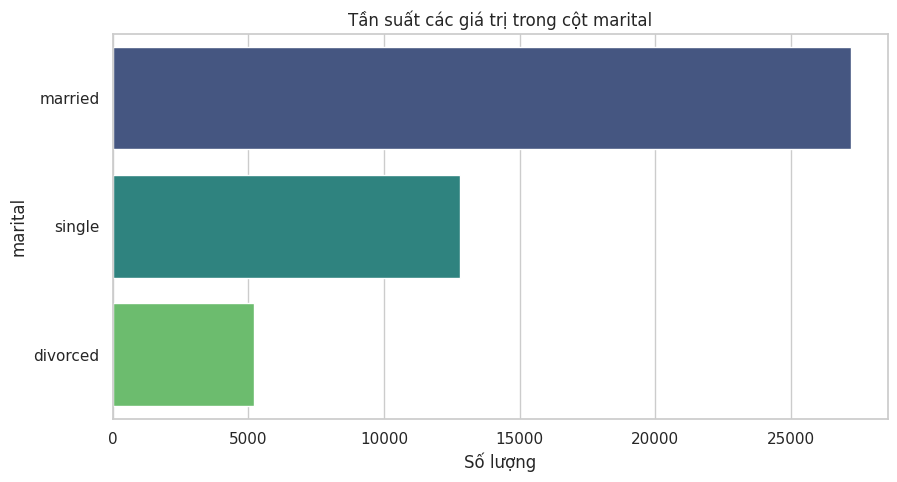

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


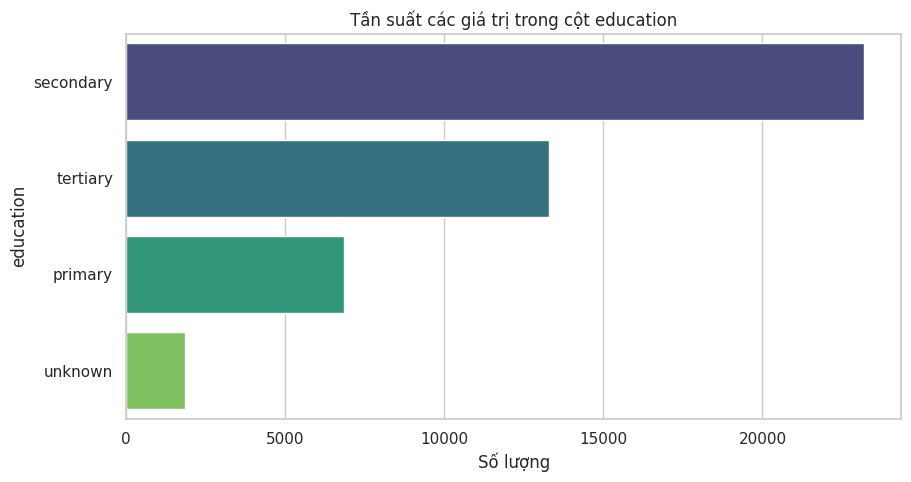

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


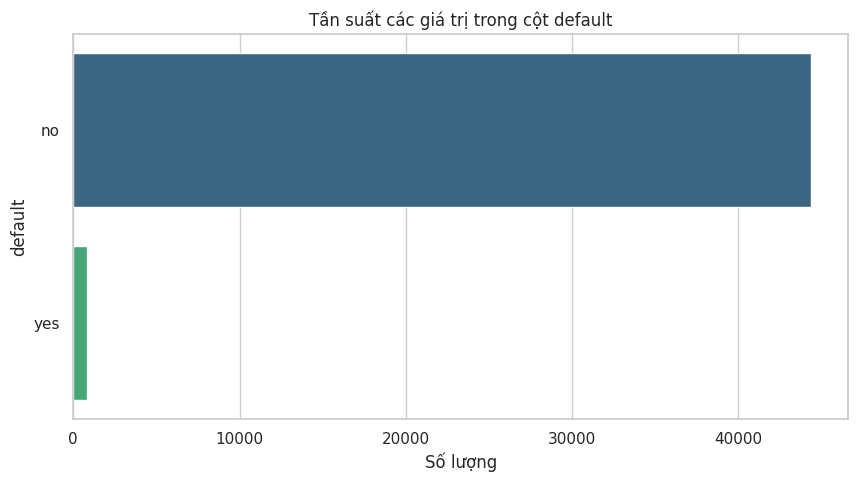

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


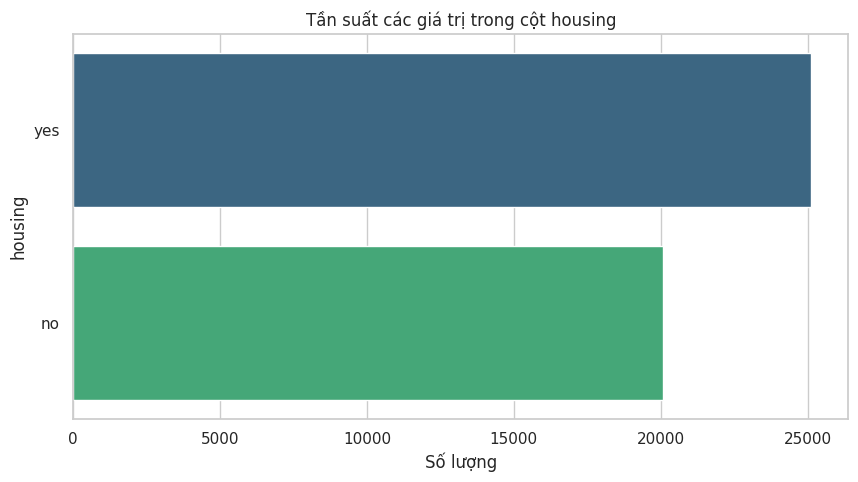

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


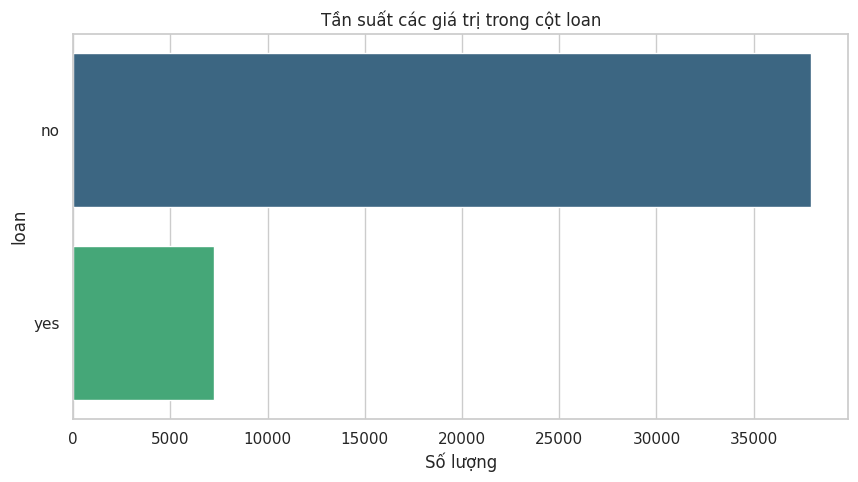

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


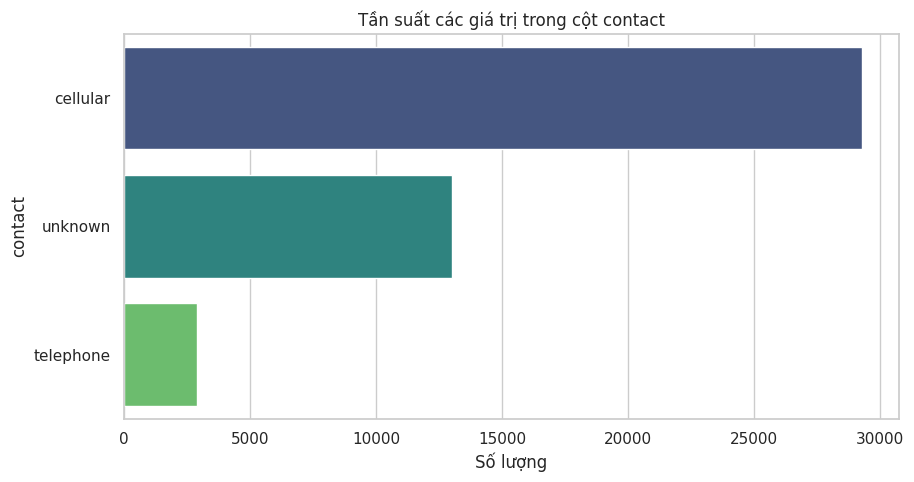

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


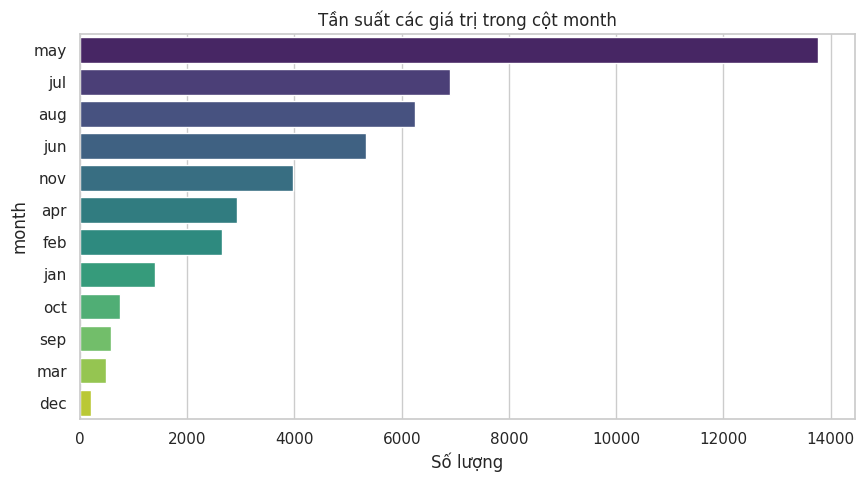

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


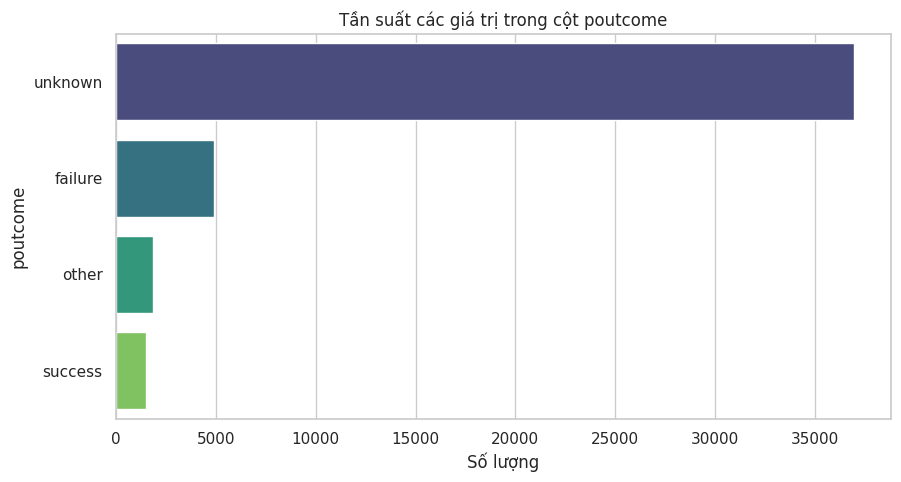

/tmp/ipykernel_1585/3553909173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')


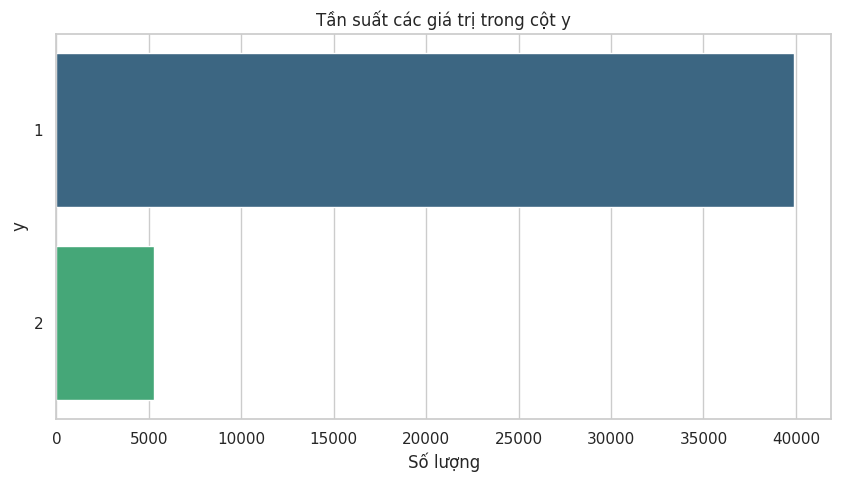

In [ ]:
# 3.2 Trực quan hóa biến định tính (Categorical)
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    # Tính toán tần suất và vẽ biểu đồ cột
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, palette='viridis')
    plt.title(f'Tần suất các giá trị trong cột {col}')
    plt.xlabel('Số lượng')
    plt.ylabel(col)
    plt.show()

In [ ]:
# 3.3 Phân tích cụ thể các ngoại lệ (Outliers) bằng IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("--- Thống kê Outliers theo phương pháp IQR ---")
for col in num_cols:
    count, lb, ub = detect_outliers_iqr(df, col)
    percentage = (count / len(df)) * 100
    print(f"{col}: {count} outliers ({percentage:.2f}%) | Ngưỡng: [{lb:.2f}, {ub:.2f}]")

--- Thống kê Outliers theo phương pháp IQR ---
age: 487 outliers (1.08%) | Ngưỡng: [10.50, 70.50]
balance: 4729 outliers (10.46%) | Ngưỡng: [-1962.00, 3462.00]
day: 0 outliers (0.00%) | Ngưỡng: [-11.50, 40.50]
duration: 3235 outliers (7.16%) | Ngưỡng: [-221.00, 643.00]
campaign: 3064 outliers (6.78%) | Ngưỡng: [-2.00, 6.00]
pdays: 8257 outliers (18.26%) | Ngưỡng: [-1.00, -1.00]
previous: 8257 outliers (18.26%) | Ngưỡng: [0.00, 0.00]


  Insight từ Univariate

1.  **Biến định lượng (Numerical):**
    *   **Age:** Tập trung chủ yếu ở độ tuổi lao động (30-50). Có một lượng nhỏ khách hàng trên 70 tuổi (outliers).
    *   **Balance:** Độ lệch rất lớn. Đa số có số dư thấp, nhưng tồn tại những khách hàng có số dư cực cao, ảnh hưởng đến giá trị trung bình.
    *   **Duration:** Hầu hết các cuộc gọi kết thúc nhanh chóng. Những cuộc gọi rất dài thường là ngoại lệ.
    *   **Campaign:** Thang đo Log cho thấy dù phần lớn chỉ bị liên hệ 1-3 lần, vẫn có những trường hợp cá biệt bị gọi tới hơn 50 lần, có thể gây phiền hà cho khách hàng.
    *   **Pdays & Previous:** Đa số giá trị là -1 và 0, xác nhận đây là tập khách hàng mới chưa từng được tiếp cận trong các chiến dịch trước đó.

2.  **Biến định tính (Categorical):**
    *   **Job & Education:** Các nhóm phổ biến nhất là lao động chân tay (blue-collar), quản lý (management) và trình độ trung học (secondary).
    *   **Target Variable (y):** Tỷ lệ khách hàng đồng ý (yes) chỉ chiếm khoảng 11.7%, cho thấy sự mất cân bằng dữ liệu (class imbalance) cần được xử lý khi huấn luyện mô hình.

##4.Phân tích target: phân phối lớp, class imbalance, baseline và numerical features theo target

/tmp/ipykernel_1585/4288991688.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y', data=df, palette=['#1f77b4', '#ff7f0e'])


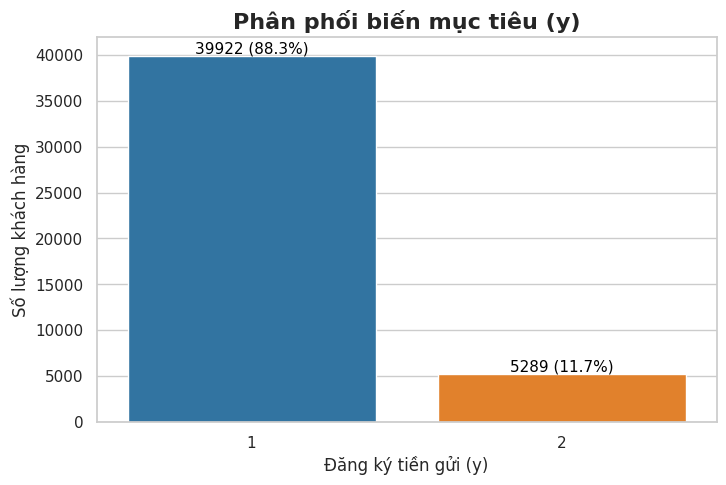

Tỷ lệ Baseline (Majority Class): 88.30%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 4.1 Phân tích phân phối biến mục tiêu (Target Distribution)
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='y', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Phân phối biến mục tiêu (y)', fontsize=16, fontweight='bold')
plt.xlabel('Đăng ký tiền gửi (y)', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

# Thêm nhãn % trên cột
for i, p in enumerate(ax.patches):
    ax.annotate(f'{target_counts.iloc[i]} ({target_pct.iloc[i]:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

print(f"Tỷ lệ Baseline (Majority Class): {target_pct.max():.2f}%")

Class Imbalance — mất cân bằng lớp

/tmp/ipykernel_1585/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_1585/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_1585/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_1585/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` i

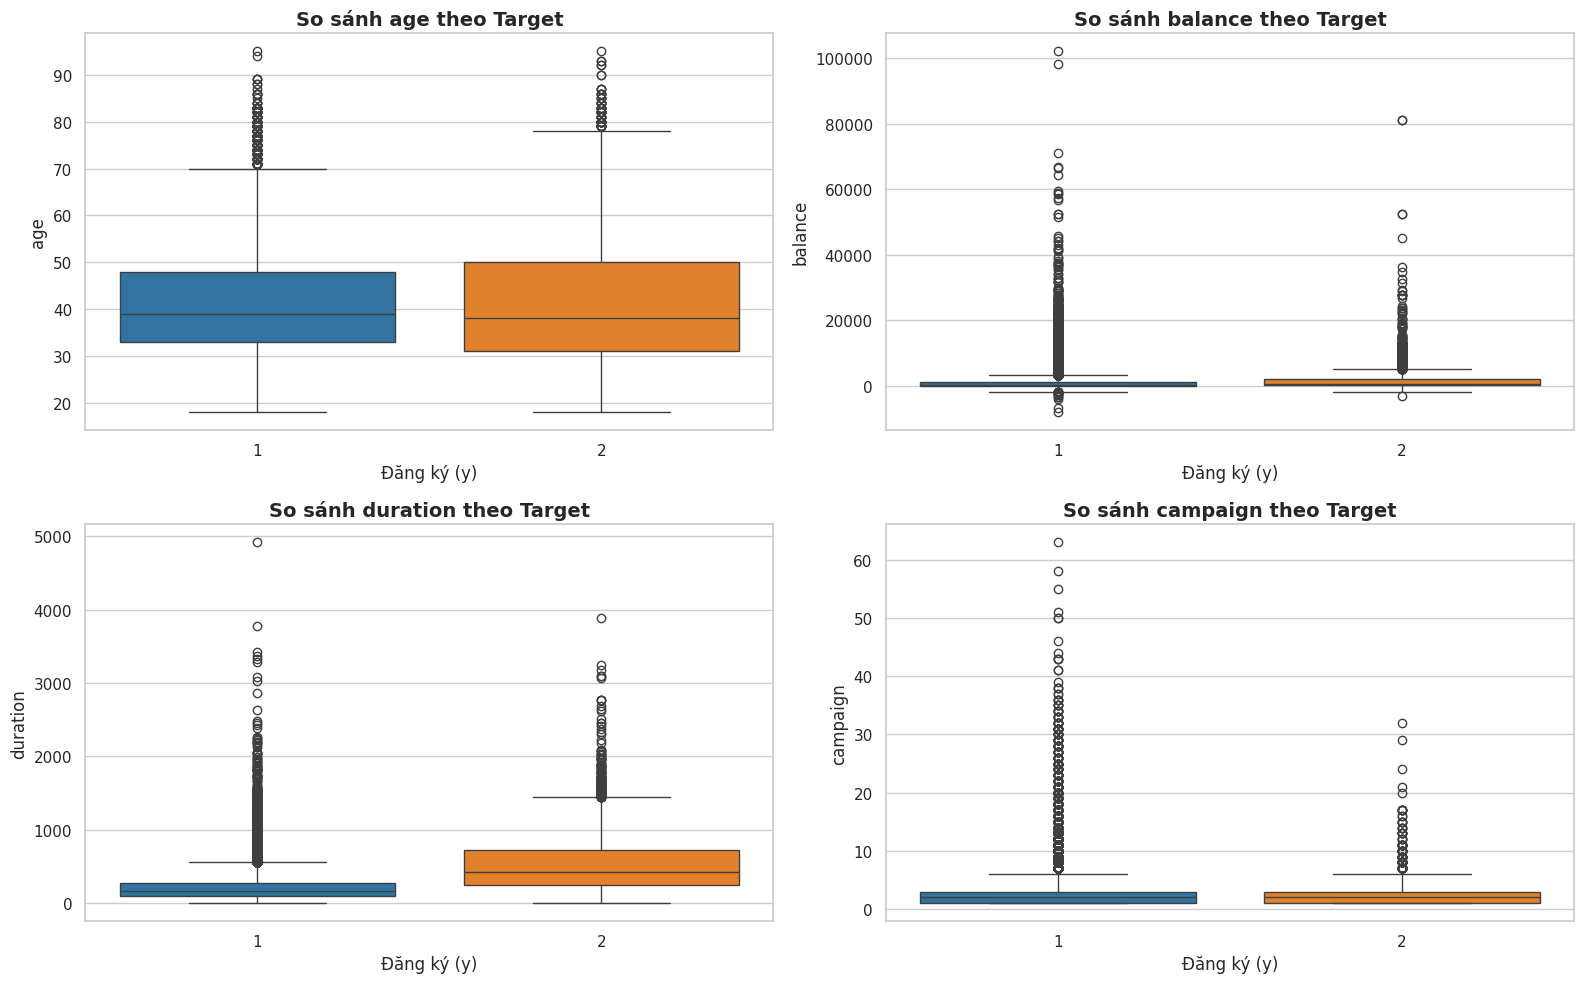

In [ ]:
# 4.2 Phân tích các biến định lượng theo Target
num_cols_to_plot = ['age', 'balance', 'duration', 'campaign']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_to_plot):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'So sánh {col} theo Target', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Đăng ký (y)', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()

Nhận xét từ phân tích Target:

1.  **Class Imbalance:** Dữ liệu bị mất cân bằng nghiêm trọng. Nhóm không đăng ký (no) chiếm **~88.3%**, trong khi nhóm đăng ký (yes) chỉ chiếm **~11.7%**.
2.  **Thời lượng cuộc gọi (Duration):** Biểu đồ boxplot cho thấy những khách hàng đồng ý (yes) thường có thời lượng cuộc gọi dài hơn rõ rệt so với nhóm 'no'. Đây là một đặc trưng mạnh nhưng cần lưu ý vì nó là biến phát sinh sau khi thực hiện cuộc gọi.
3.  **Số dư (Balance):** Không có sự khác biệt quá lớn về trung vị, nhưng nhóm 'yes' dường như có phân phối số dư ổn định hơn ở một số phân khúc nhất định.
4.  **Chiến dịch (Campaign):** Nhóm đồng ý (yes) thường có số lần liên hệ ít hơn trong chiến dịch hiện tại so với nhóm bị liên hệ quá nhiều lần mà vẫn từ chối.

 ## 5.Categorical → target: crosstab, conversion rate, job, marital, education, contact, poutcome

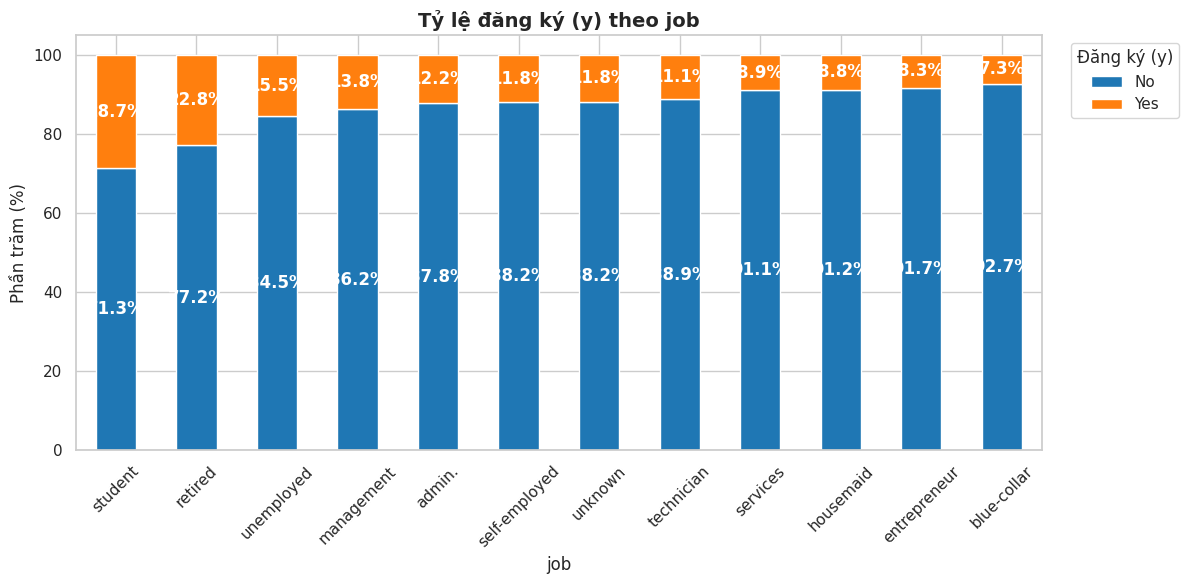

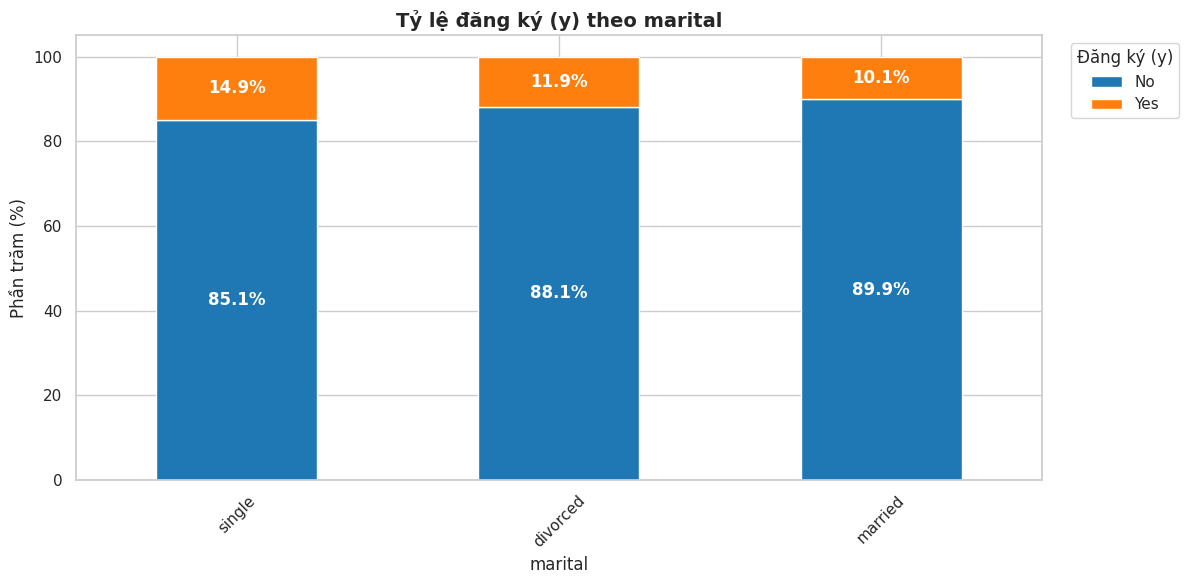

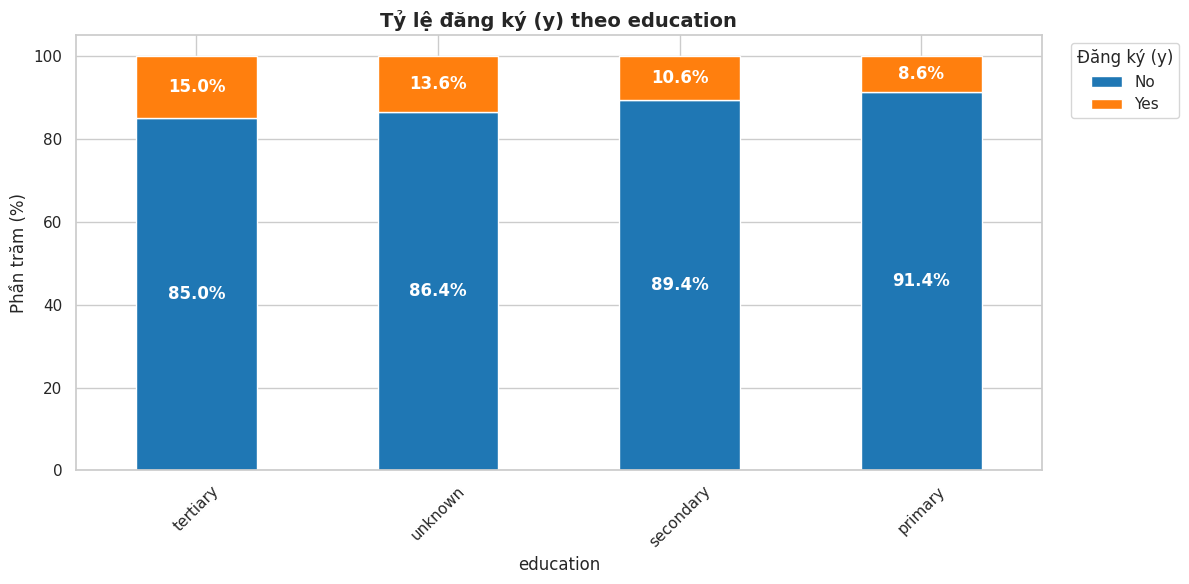

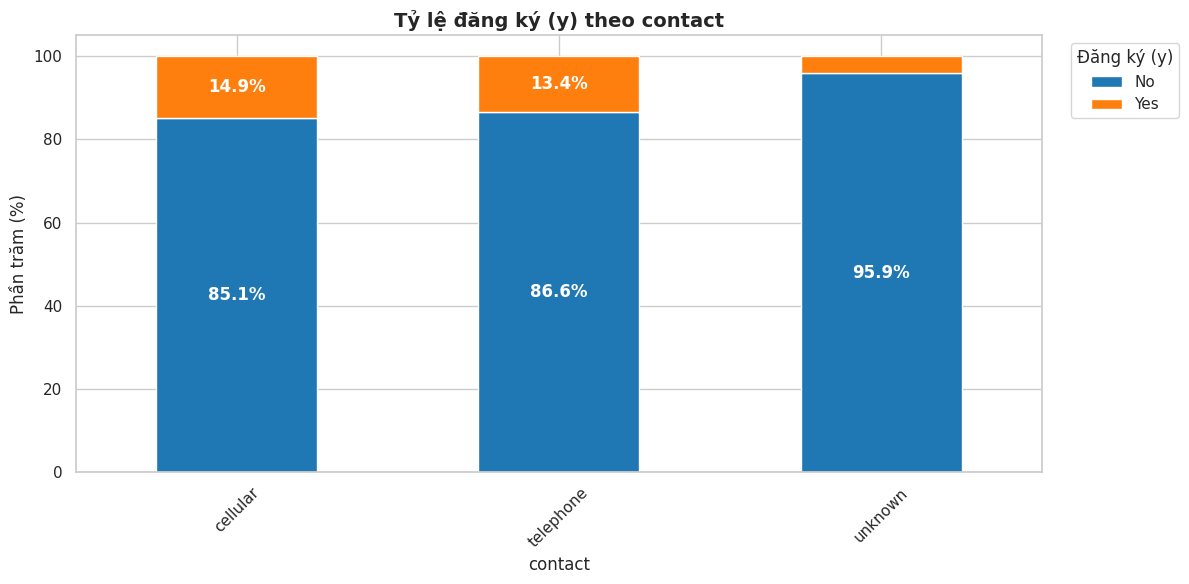

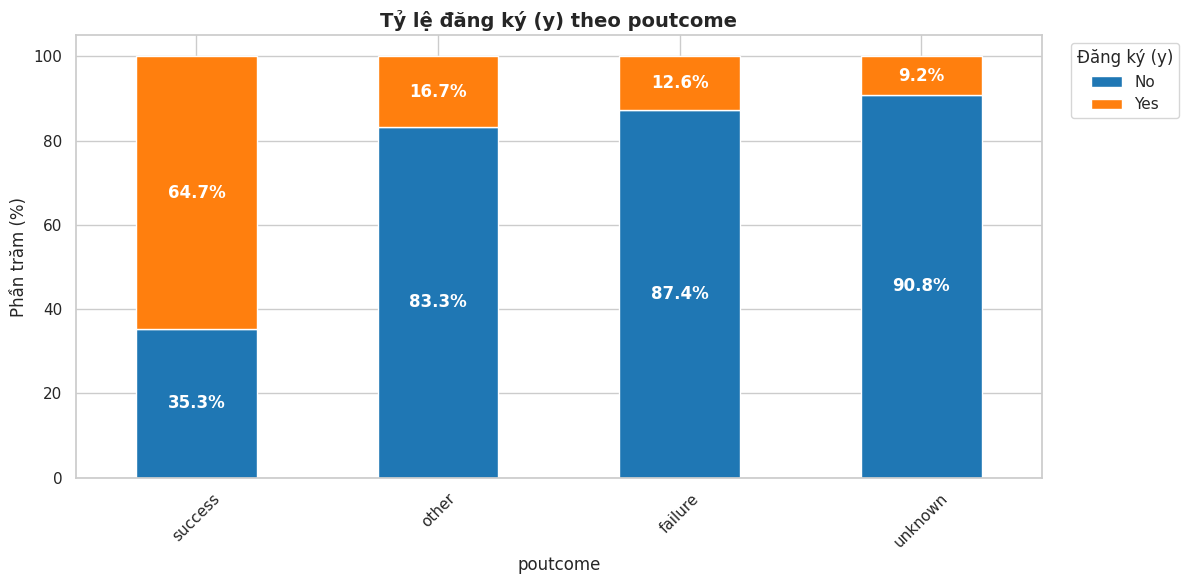

In [ ]:
# 4.3 Phân tích các biến định tính theo Target (Tỷ lệ chuyển đổi)
cat_cols_to_plot = ['job', 'marital', 'education', 'contact', 'poutcome']

for col in cat_cols_to_plot:
    # Tính toán tỷ lệ phần trăm
    props = df.groupby(col)['y'].value_counts(normalize=True).unstack() * 100
    # Sắp xếp theo tỷ lệ 'yes' (giả sử nhãn là 2 hoặc 'yes')
    props = props.sort_values(by=props.columns[1], ascending=False)

    ax = props.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])

    plt.title(f'Tỷ lệ đăng ký (y) theo {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Phần trăm (%)', fontsize=12)
    plt.legend(title='Đăng ký (y)', labels=['No', 'Yes'], loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.xticks(rotation=45)

    # Thêm nhãn % lên các phân đoạn biểu đồ
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if height > 5: # Chỉ hiển thị nhãn nếu vùng đủ lớn
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    horizontalalignment='center', verticalalignment='center',
                    color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

**Insight từ phân tích Categorical vs Target:**

1.  **Poutcome :** Những khách hàng đã từng 'success' ở chiến dịch trước có tỷ lệ đồng ý cực cao ở chiến dịch này (>60%). Đây là đặc trưng quan trọng nhất.
2.  **Job :** Học sinh/sinh viên và người nghỉ hưu có tỷ lệ đăng ký cao hơn hẳn mặt bằng chung.
3.  **Contact (Hình thức liên lạc):** Liên lạc qua di động ('cellular') hiệu quả hơn nhiều so với điện thoại bàn hoặc không rõ thông tin.
4.  **Education (Học vấn):** Nhóm có trình độ học vấn cao (tertiary) thường có xu hướng gửi tiết kiệm nhiều hơn.

--- PHÂN TÍCH CHI TIẾT TỶ LỆ CHUYỂN ĐỔI (CONVERSION RATE) ---

Bảng thống kê cho cột: job


y,1,2,Total,Conversion Rate (%)
job,,,,
student,669,269,938,28.678038
retired,1748,516,2264,22.791519
unemployed,1101,202,1303,15.502686
management,8157,1301,9458,13.755551
admin.,4540,631,5171,12.202669
self-employed,1392,187,1579,11.842939
unknown,254,34,288,11.805556
technician,6757,840,7597,11.056996
services,3785,369,4154,8.883004


--------------------------------------------------


/tmp/ipykernel_1585/44360704.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ct.index, y=ct['Conversion Rate (%)'], palette='magma')


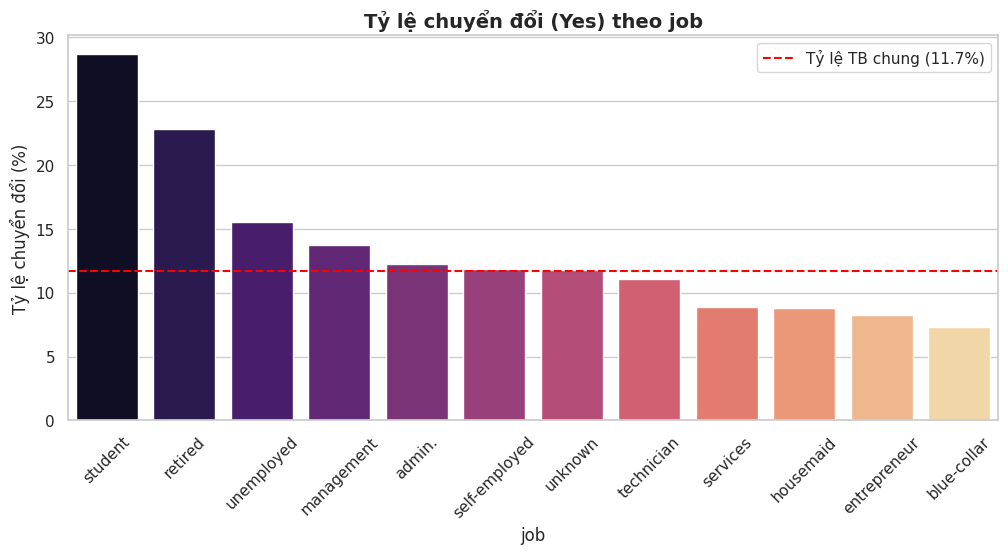

Bảng thống kê cho cột: marital


y,1,2,Total,Conversion Rate (%)
marital,,,,
single,10878,1912,12790,14.949179
divorced,4585,622,5207,11.945458
married,24459,2755,27214,10.123466


--------------------------------------------------


/tmp/ipykernel_1585/44360704.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ct.index, y=ct['Conversion Rate (%)'], palette='magma')


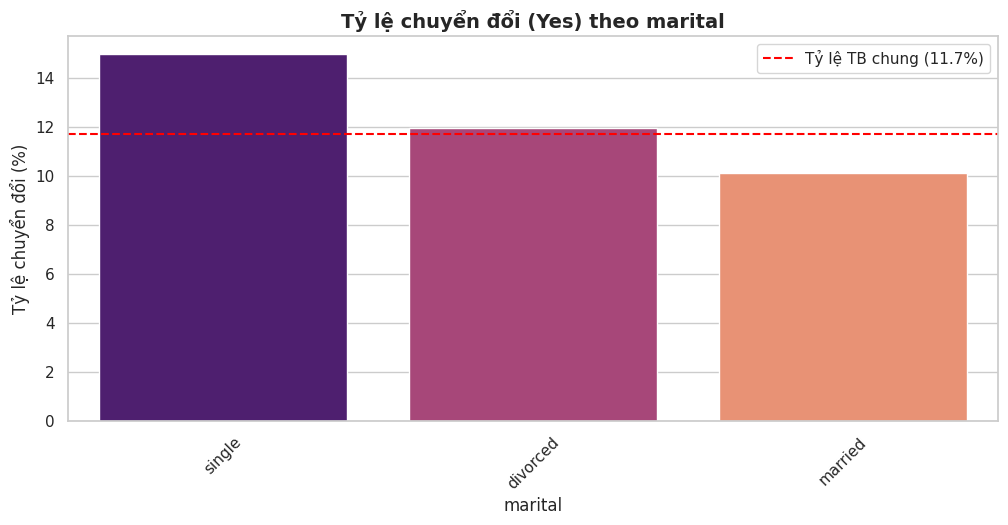

Bảng thống kê cho cột: education


y,1,2,Total,Conversion Rate (%)
education,,,,
tertiary,11305,1996,13301,15.006390
unknown,1605,252,1857,13.570275
secondary,20752,2450,23202,10.559435
primary,6260,591,6851,8.626478


--------------------------------------------------


/tmp/ipykernel_1585/44360704.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ct.index, y=ct['Conversion Rate (%)'], palette='magma')


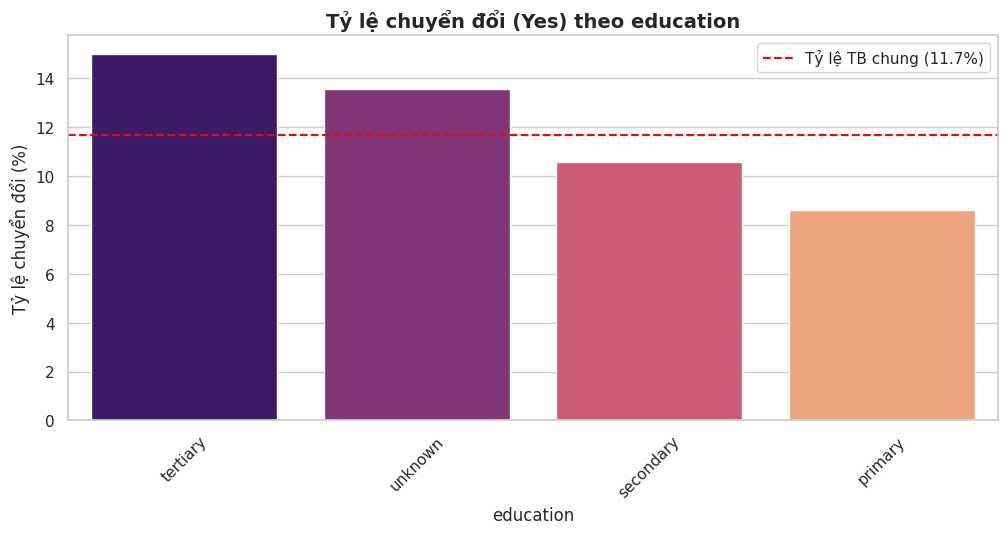

Bảng thống kê cho cột: contact


y,1,2,Total,Conversion Rate (%)
contact,,,,
cellular,24916,4369,29285,14.918900
telephone,2516,390,2906,13.420509
unknown,12490,530,13020,4.070661


--------------------------------------------------


/tmp/ipykernel_1585/44360704.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ct.index, y=ct['Conversion Rate (%)'], palette='magma')


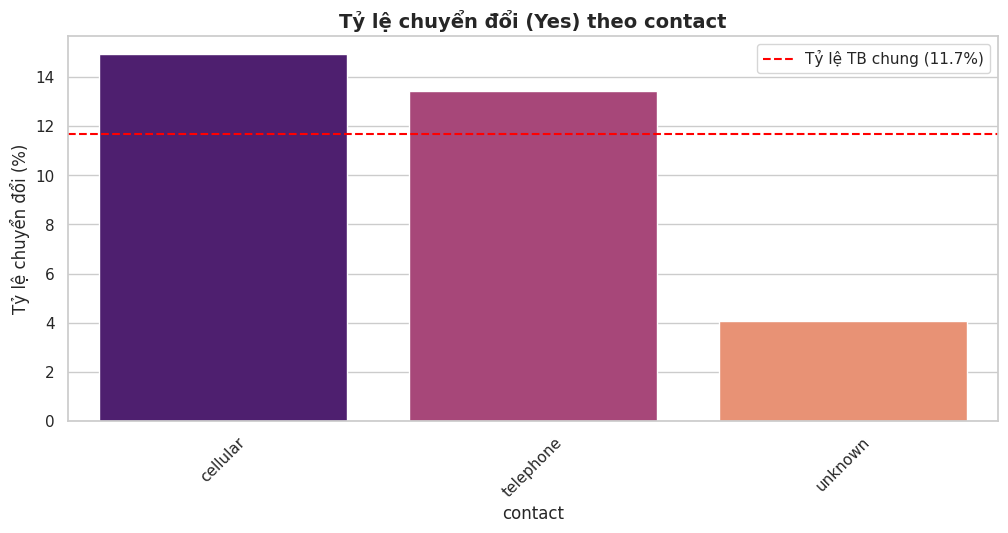

Bảng thống kê cho cột: poutcome


y,1,2,Total,Conversion Rate (%)
poutcome,,,,
success,533,978,1511,64.725347
other,1533,307,1840,16.684783
failure,4283,618,4901,12.609671
unknown,33573,3386,36959,9.161503


--------------------------------------------------


/tmp/ipykernel_1585/44360704.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ct.index, y=ct['Conversion Rate (%)'], palette='magma')


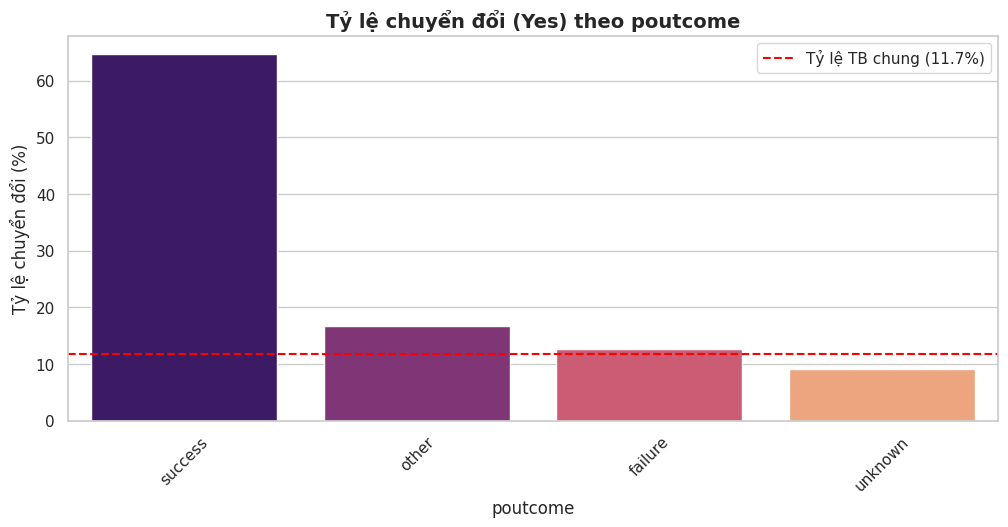

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các cột định tính quan trọng
selected_cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

# Tạo một DataFrame trống để lưu trữ Insight tổng hợp
conversion_insights = []

print("--- PHÂN TÍCH CHI TIẾT TỶ LỆ CHUYỂN ĐỔI (CONVERSION RATE) ---\n")

for col in selected_cat_cols:
    # 1. Tạo bảng chéo (Crosstab)
    ct = pd.crosstab(df[col], df['y'])

    # 2. Tính Tỷ lệ chuyển đổi (Conversion Rate %)
    # Lưu ý: '2' tương ứng với 'yes' trong dataset này sau khi load
    ct['Total'] = ct.sum(axis=1)
    ct['Conversion Rate (%)'] = (ct['2'] / ct['Total']) * 100
    ct = ct.sort_values(by='Conversion Rate (%)', ascending=False)

    print(f"Bảng thống kê cho cột: {col}")
    display(ct)
    print("-" * 50)

    # 3. Vẽ biểu đồ Bar chart so sánh Conversion Rate
    plt.figure(figsize=(12, 5))
    sns.barplot(x=ct.index, y=ct['Conversion Rate (%)'], palette='magma')

    # Thêm đường trung bình chung để so sánh (baseline ~11.7%)
    plt.axhline(y=11.7, color='red', linestyle='--', label='Tỷ lệ TB chung (11.7%)')

    plt.title(f'Tỷ lệ chuyển đổi (Yes) theo {col}', fontsize=14, fontweight='bold')
    plt.ylabel('Tỷ lệ chuyển đổi (%)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

**Phân tích chi tiết và Insight chuyên sâu:**

1.  **Chiến lược dựa trên `poutcome` (Kết quả trước đó):**
    *   **Insight:** Khách hàng từng thành công (`success`) có tỷ lệ chuyển đổi lên tới **>60%**, cao gấp 5 lần mức trung bình.
    *   **Hành động:** Đây là nhóm khách hàng "vàng". Cần ưu tiên tối đa nguồn lực chăm sóc lại nhóm này.

2.  **Đặc điểm nghề nghiệp (`job`):**
    *   **Insight:** `student` (sinh viên) và `retired` (người già) có tỷ lệ đồng ý cao nhất. Nhóm `blue-collar` (lao động tay chân) chiếm số lượng đông nhất nhưng tỷ lệ đồng ý lại thấp nhất.
    *   **Hành động:** Thiết kế các gói tiền gửi tiết kiệm dành riêng cho sinh viên (tích lũy) và người nghỉ hưu (an dưỡng) để tối ưu hóa conversion rate.

3.  **Tình trạng hôn nhân (`marital`) & Học vấn (`education`):**
    *   **Insight:** Người độc thân (`single`) và người có học vấn cao (`tertiary`) có xu hướng cởi mở hơn với các sản phẩm tài chính.
    *   **Hành động:** Tập trung các chiến dịch quảng cáo qua kênh kỹ thuật số hướng đến đối tượng trẻ, độc thân, có trình độ.

4.  **Kênh liên lạc (`contact`):**
    *   **Insight:** Liên lạc qua di động (`cellular`) vượt trội hơn hẳn so với điện thoại bàn. Đặc biệt, nhóm `unknown` có tỷ lệ rất thấp.
    *   **Hành động:** Làm sạch dữ liệu, cập nhật số điện thoại di động của khách hàng để thay thế các số điện thoại bàn hoặc thông tin bị thiếu.

## 6.Correlation
- numerical vs numerical  
- cat vs cat
- num vs cat  
- Chi-square  và tổng hợp insight EDA

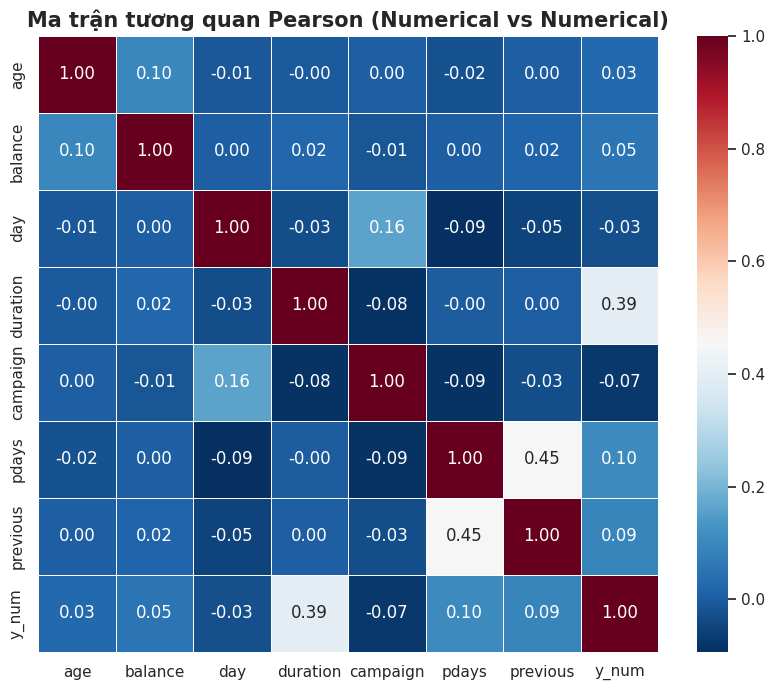

In [ ]:
#numerical vs numerical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Định nghĩa lại các cột số để tránh lỗi NameError
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# --- 6.1 Tương quan Định lượng vs Định lượng (Pearson) ---
plt.figure(figsize=(10, 8))

# Chuẩn bị dữ liệu: Copy df và map y sang dạng số (1->0, 2->1) để tính tương quan
df_corr = df.copy()
df_corr['y_num'] = df_corr['y'].map({'1': 0, '2': 1})

corr_matrix = df_corr[list(num_cols) + ['y_num']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan Pearson (Numerical vs Numerical)', fontsize=15, fontweight='bold')
plt.show()

 Phân tích tương quan Định tính vs Định tính (Categorical vs Categorical)
 kiểm định Chi-square và hệ số Cramer's V để đo lường mức độ liên kết giữa các đặc trưng định tính và biến mục tiêu.

/tmp/ipykernel_1585/2260301651.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Cramer's V", y='Biến', data=cramers_df, palette='magma')


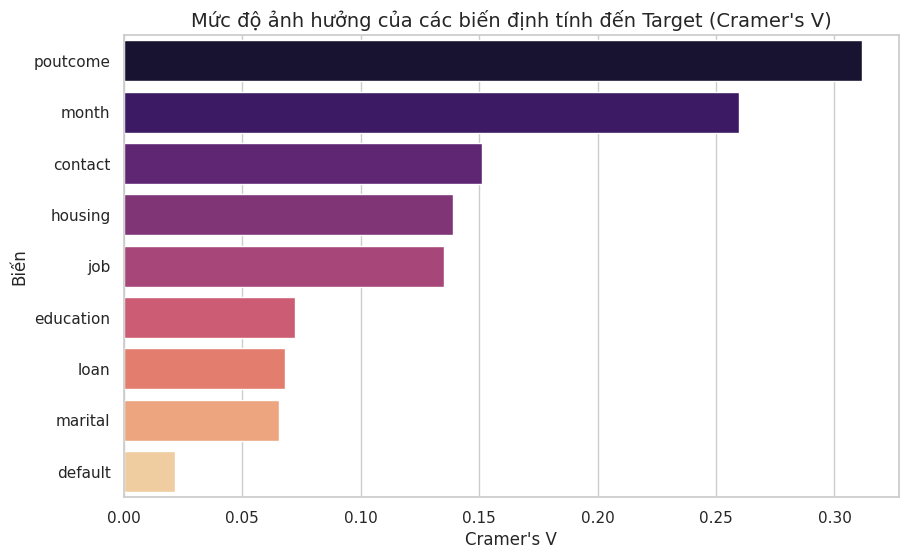

,Biến,Cramer's V
8,poutcome,0.311560
7,month,0.259772
6,contact,0.151211
4,housing,0.139025
0,job,0.135094
2,education,0.072238
5,loan,0.067929
1,marital,0.065590
3,default,0.021656


In [ ]:
#Categorical vs Categorical
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols_analysis = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

results = []
for col in cat_cols_analysis:
    v = cramers_v(df[col], df['y'])
    results.append({'Biến': col, "Cramer's V": v})

cramers_df = pd.DataFrame(results).sort_values(by="Cramer's V", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Cramer's V", y='Biến', data=cramers_df, palette='magma')
plt.title("Mức độ ảnh hưởng của các biến định tính đến Target (Cramer's V)", fontsize=14)
plt.show()

display(cramers_df)

Phân tích tương quan Định lượng vs Định tính (Numerical vs Categorical)


--- GIÁ TRỊ TRUNG BÌNH CÁC BIẾN SỐ THEO NHÓM TARGET ---


,age,balance,day,duration,campaign,pdays,previous
y,,,,,,,
1,40.838986,1303.714969,15.892290,221.182806,2.846350,36.421372,0.502154
2,41.670070,1804.267915,15.158253,537.294574,2.141047,68.702968,1.170354


/tmp/ipykernel_1585/4030713077.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='duration', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_1585/4030713077.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='balance', data=df, ax=axes[1], palette='magma')


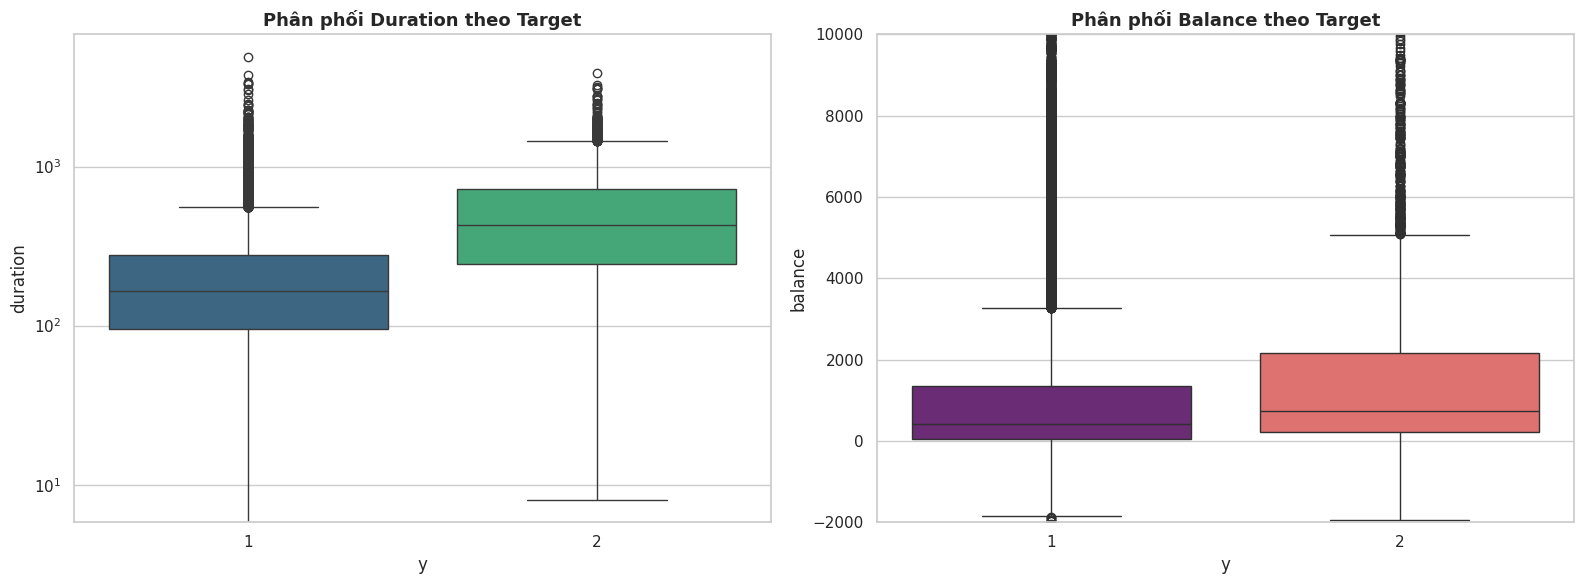

In [ ]:
#Numerical vs Categorical
import matplotlib.pyplot as plt
import seaborn as sns

# Xác định lại danh sách cột số
num_cols_analysis = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

print("--- GIÁ TRỊ TRUNG BÌNH CÁC BIẾN SỐ THEO NHÓM TARGET ---")
summary_stats = df.groupby('y')[num_cols_analysis].mean()
display(summary_stats)

# Trực quan hóa sự khác biệt rõ rệt nhất: Duration và Balance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='y', y='duration', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Phân phối Duration theo Target', fontsize=13, fontweight='bold')
axes[0].set_yscale('log') # Dùng log scale vì duration có nhiều outlier

sns.boxplot(x='y', y='balance', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Phân phối Balance theo Target', fontsize=13, fontweight='bold')
axes[1].set_ylim(-2000, 10000) # Giới hạn để dễ quan sát vùng tập trung

plt.tight_layout()
plt.show()

--- THỐNG KÊ MÔ TẢ BIẾN SỐ THEO NHÓM TARGET ---


,age,balance,day,duration,campaign,pdays,previous
y,,,,,,,
1,40.838986,1303.714969,15.892290,221.182806,2.846350,36.421372,0.502154
2,41.670070,1804.267915,15.158253,537.294574,2.141047,68.702968,1.170354


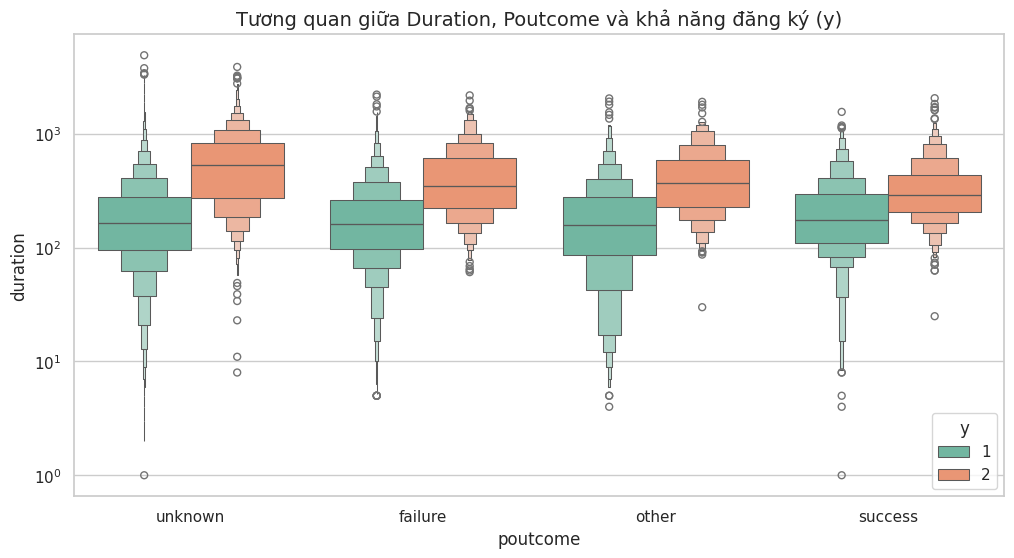

In [ ]:
# Định nghĩa lại num_cols
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# --- 6.3 Tương quan Định lượng vs Định tính (Numerical vs Categorical) ---
print("--- THỐNG KÊ MÔ TẢ BIẾN SỐ THEO NHÓM TARGET ---")
display(df.groupby('y')[num_cols].mean())

# Trực quan hóa tương quan mạnh nhất: Duration vs Poutcome
plt.figure(figsize=(12, 6))
sns.boxenplot(x='poutcome', y='duration', hue='y', data=df, palette='Set2')
plt.title('Tương quan giữa Duration, Poutcome và khả năng đăng ký (y)', fontsize=14)
plt.yscale('log') # Dùng thang log vì duration có outlier lớn
plt.show()

 Phân tích tương quan giữa các cặp biến độc lập (Feature vs Feature)
Việc này giúp hiểu rõ hơn về chân dung khách hàng và loại bỏ các biến bị trùng lặp thông tin.

/tmp/ipykernel_1585/3250384324.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='education', y='balance', data=df, palette='viridis')


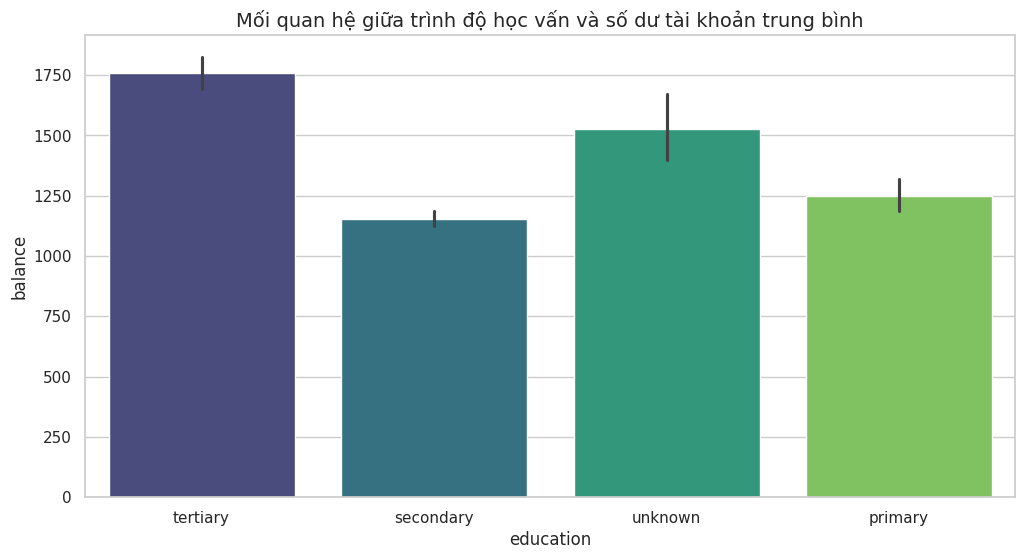

/tmp/ipykernel_1585/3250384324.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='job', y='age', data=df, palette='magma')


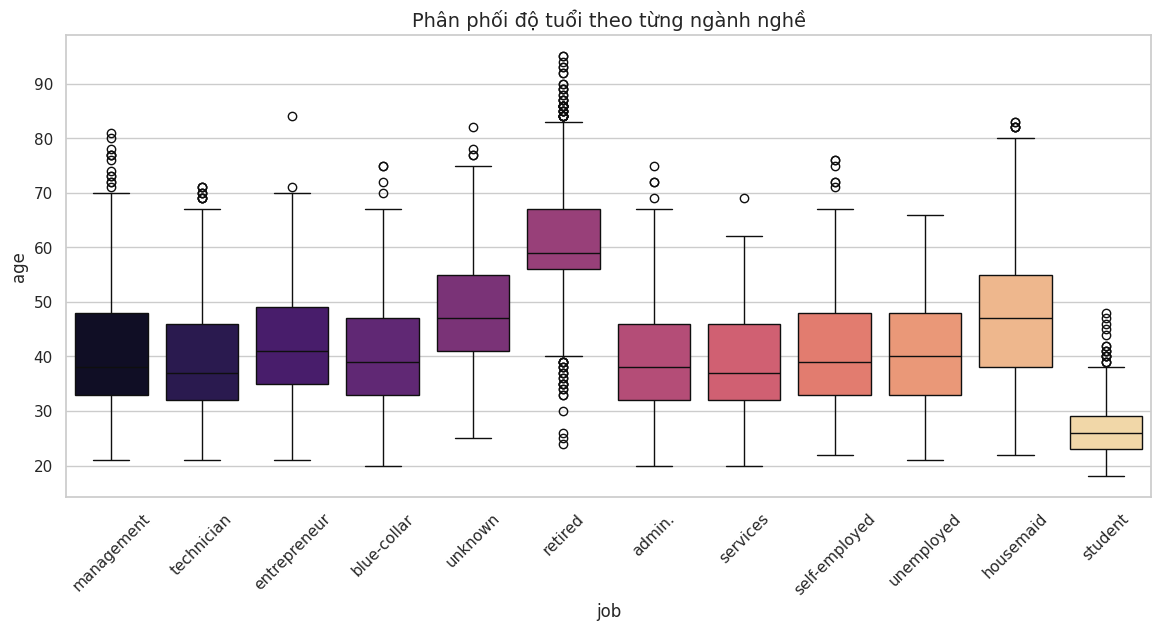

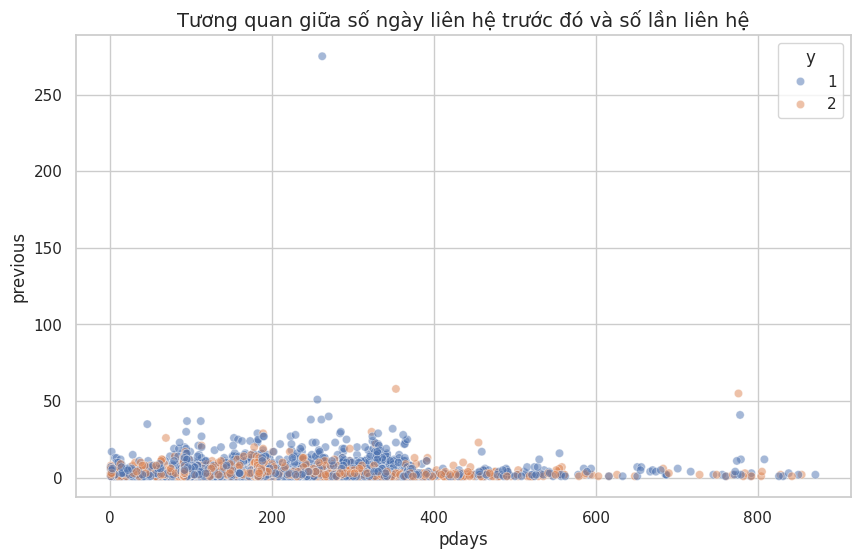

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mối quan hệ giữa Học vấn và Số dư tài khoản (Education vs Balance)
plt.figure(figsize=(12, 6))
sns.barplot(x='education', y='balance', data=df, palette='viridis')
plt.title('Mối quan hệ giữa trình độ học vấn và số dư tài khoản trung bình', fontsize=14)
plt.show()

# 2. Mối quan hệ giữa Nghề nghiệp và Tuổi (Job vs Age)
plt.figure(figsize=(14, 6))
sns.boxplot(x='job', y='age', data=df, palette='magma')
plt.xticks(rotation=45)
plt.title('Phân phối độ tuổi theo từng ngành nghề', fontsize=14)
plt.show()

# 3. Mối quan hệ giữa pdays và previous (Tương quan định lượng mạnh nhất)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pdays', y='previous', hue='y', data=df[df['pdays'] != -1], alpha=0.5)
plt.title('Tương quan giữa số ngày liên hệ trước đó và số lần liên hệ', fontsize=14)
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

# Định nghĩa lại các cột định tính
cat_cols = df.select_dtypes(include=['object']).columns

print("--- KIỂM ĐỊNH CHI-SQUARE (Categorical vs Target y) ---\n")
chi2_results = []

for col in cat_cols:
    if col == 'y': continue

    # Tạo bảng tần suất
    contingency_table = pd.crosstab(df[col], df['y'])

    # Kiểm định Chi-square
    chi2, p, dof, ex = chi2_contingency(contingency_table)

    chi2_results.append({
        'Biến': col,
        'Chi2 Statistic': chi2,
        'P-value': p,
        'Ý nghĩa (P < 0.05)': 'Có' if p < 0.05 else 'Không'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values(by='Chi2 Statistic', ascending=False)
display(chi2_df)

print("\nGiải thích: Chi2 Statistic càng cao và P-value càng nhỏ (<0.05) chứng tỏ biến đó có ảnh hưởng mạnh đến biến mục tiêu.")

--- KIỂM ĐỊNH CHI-SQUARE (Categorical vs Target y) ---



,Biến,Chi2 Statistic,P-value,Ý nghĩa (P < 0.05)
8,poutcome,4391.506589,0.000000e+00,Có
7,month,3061.838938,0.000000e+00,Có
6,contact,1035.714225,1.251738e-225,Có
4,housing,874.822449,2.918798e-192,Có
0,job,836.105488,3.337122e-172,Có
2,education,238.923506,1.626656e-51,Có
5,loan,209.616980,1.665061e-47,Có
1,marital,196.495946,2.145100e-43,Có
3,default,22.202250,2.453861e-06,Có



Giải thích: Chi2 Statistic càng cao và P-value càng nhỏ (<0.05) chứng tỏ biến đó có ảnh hưởng mạnh đến biến mục tiêu.


 TỔNG HỢP  INSIGHT TỪ EDA

Sau khi phân tích chi tiết, chúng ta có các kết luận quan trọng để xây dựng mô hình:

1.  **Biến quan trọng nhất (Top Drivers):**
    *   **Duration:** Thời lượng cuộc gọi là yếu tố dự báo mạnh nhất. Cuộc gọi càng lâu, xác suất đồng ý càng cao.
    *   **Poutcome (Success):** Những người đã đồng ý ở chiến dịch trước có tỷ lệ quay lại cực cao (>64%).
    *   **Contact:** Kênh `cellular` (di động) mang lại hiệu quả vượt trội so với các kênh khác.

2.  **Mối quan hệ giữa các biến (Correlations):**
    *   `pdays` và `previous` có tương quan thuận mạnh (~0.45). Điều này dễ hiểu vì chúng cùng phản ánh lịch sử liên hệ.
    *   Không có hiện tượng đa cộng tuyến (multicollinearity) nghiêm trọng giữa các biến độc lập, giúp mô hình ổn định.

3.  **Thách thức về Dữ liệu:**
    *   **Class Imbalance:** Tỷ lệ 88% - 12% là một trở ngại lớn. Cần cân nhắc các kỹ thuật như **SMOTE** hoặc điều chỉnh **class_weight** khi training.
    *   **Missing/Unknown Values:** Cột `poutcome` và `contact` có lượng `unknown` rất lớn. Cần xử lý khéo léo để không làm mất thông tin.
    *   **Outliers:** `balance` và `duration` có các giá trị cực biên rất lớn, có thể cần xử lý bằng Robust Scaling hoặc Capping.

#III.Data Preparation

##7.Data cleaning: missing/unknown, duplicate, invalid values và quyết định xử lý outlier

In [ ]:
import numpy as np

# 1. Chuyển 'unknown' thành NaN để kiểm tra tổng quan (tùy chọn)
# Tuy nhiên, với poutcome, 'unknown' mang ý nghĩa là khách hàng mới, ta sẽ giữ lại nhóm này.

# 2. Loại bỏ các cột không cần thiết hoặc gây đa cộng tuyến
# pdays và previous tương quan mạnh, ta giữ lại previous vì pdays có quá nhiều giá trị -1
df_clean = df.drop(columns=['pdays'])

# 3. Xử lý Outliers bằng phương pháp Capping (giới hạn ở percentile 1% và 99%)
def cap_outliers(series, lower_quantile=0.01, upper_quantile=0.99):
    lower_limit = series.quantile(lower_quantile)
    upper_limit = series.quantile(upper_quantile)
    return series.clip(lower=lower_limit, upper=upper_limit)

outlier_cols = ['balance', 'duration']
for col in outlier_cols:
    df_clean[col] = cap_outliers(df_clean[col])

print("Dữ liệu sau khi làm sạch và xử lý ngoại lệ:")
display(df_clean[outlier_cols].describe())
print(f"Kích thước tập dữ liệu hiện tại: {df_clean.shape}")

Dữ liệu sau khi làm sạch và xử lý ngoại lệ:


,balance,duration
count,45211.000000,45211.000000
mean,1278.121689,254.375993
std,2249.406970,234.779511
min,-627.000000,11.000000
25%,72.000000,103.000000
50%,448.000000,180.000000
75%,1428.000000,319.000000
max,13164.900000,1269.000000


Kích thước tập dữ liệu hiện tại: (45211, 16)


7.1 Xử lý giá trị thiếu (Missing values)
Kiểm tra lại xem còn giá trị null thực sự nào không sau khi đã xử lý sơ bộ.

In [ ]:
print("Số lượng giá trị Null thực sự:")
print(df_clean.isnull().sum())

# Lưu lại file đã clean để dùng cho bước encoding tiếp theo
df_clean.to_csv('bank_data_cleaned.csv', index=False)
print("\nĐã lưu dữ liệu sạch vào file: bank_data_cleaned.csv")

Số lượng giá trị Null thực sự:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
previous     0
poutcome     0
y            0
dtype: int64

Đã lưu dữ liệu sạch vào file: bank_data_cleaned.csv


##8.Encoding và feature engineering: binary, one-hot, ordinal nếu phù hợp; kiểm tra data leakage

In [ ]:
import pandas as pd
import numpy as np

# Tạo bản sao dữ liệu để xử lý
df_encoded = df_clean.copy()

# 1. Mã hóa biến mục tiêu 'y'
# Chuyển đổi: '1' hoặc 'no' -> 0, '2' hoặc 'yes' -> 1
# Dựa vào EDA trước đó, '1' là No, '2' là Yes
df_encoded['y'] = df_encoded['y'].map({'1': 0, '2': 1, 'no': 0, 'yes': 1})

# 2. Binary Encoding (0/1) cho các cột có 2 giá trị
binary_features = ['default', 'housing', 'loan']
for col in binary_features:
    df_encoded[col] = df_encoded[col].map({'no': 0, 'yes': 1})

# 3. Ordinal Encoding cho 'month'
# Việc mã hóa theo thứ tự giúp mô hình hiểu được trình tự các tháng
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
df_encoded['month'] = df_encoded['month'].map(month_map)

# 4. One-Hot Encoding cho các biến Nominal (không thứ tự)
# Sử dụng drop_first=True để tránh bẫy biến giả (Dummy Variable Trap)
nominal_features = ['job', 'marital', 'education', 'contact', 'poutcome']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_features, drop_first=True)

# Đảm bảo các cột mới tạo ra có kiểu dữ liệu int (0/1)
new_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[new_cols] = df_encoded[new_cols].astype(int)

print("--- KẾT QUẢ ENCODING ---")
print(f"Kích thước ban đầu: {df_clean.shape}")
print(f"Kích thước sau encoding: {df_encoded.shape}")
display(df_encoded.head())

--- KẾT QUẢ ENCODING ---
Kích thước ban đầu: (45211, 16)
Kích thước sau encoding: (45211, 32)


,age,default,balance,housing,loan,day,month,duration,campaign,previous,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,58.0,0,2143.0,1,0,5.0,5,261.0,1.0,0.0,...,1,0,0,1,0,0,1,0,0,1
1,44.0,0,29.0,1,0,5.0,5,151.0,1.0,0.0,...,0,1,1,0,0,0,1,0,0,1
2,33.0,0,2.0,1,1,5.0,5,76.0,1.0,0.0,...,1,0,1,0,0,0,1,0,0,1
3,47.0,0,1506.0,1,0,5.0,5,92.0,1.0,0.0,...,1,0,0,0,1,0,1,0,0,1
4,33.0,0,1.0,0,0,5.0,5,198.0,1.0,0.0,...,0,1,0,0,1,0,1,0,0,1


```markdown
### Kiểm tra Data Leakage & Tính tương quan cuối cùng
Chúng ta cần đảm bảo các biến sau khi encoding không có biến nào tương quan hoàn hảo với mục tiêu `y` (trừ chính nó) và kiểm tra lại sự phân bổ.
```

/tmp/ipykernel_1585/1458749295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')


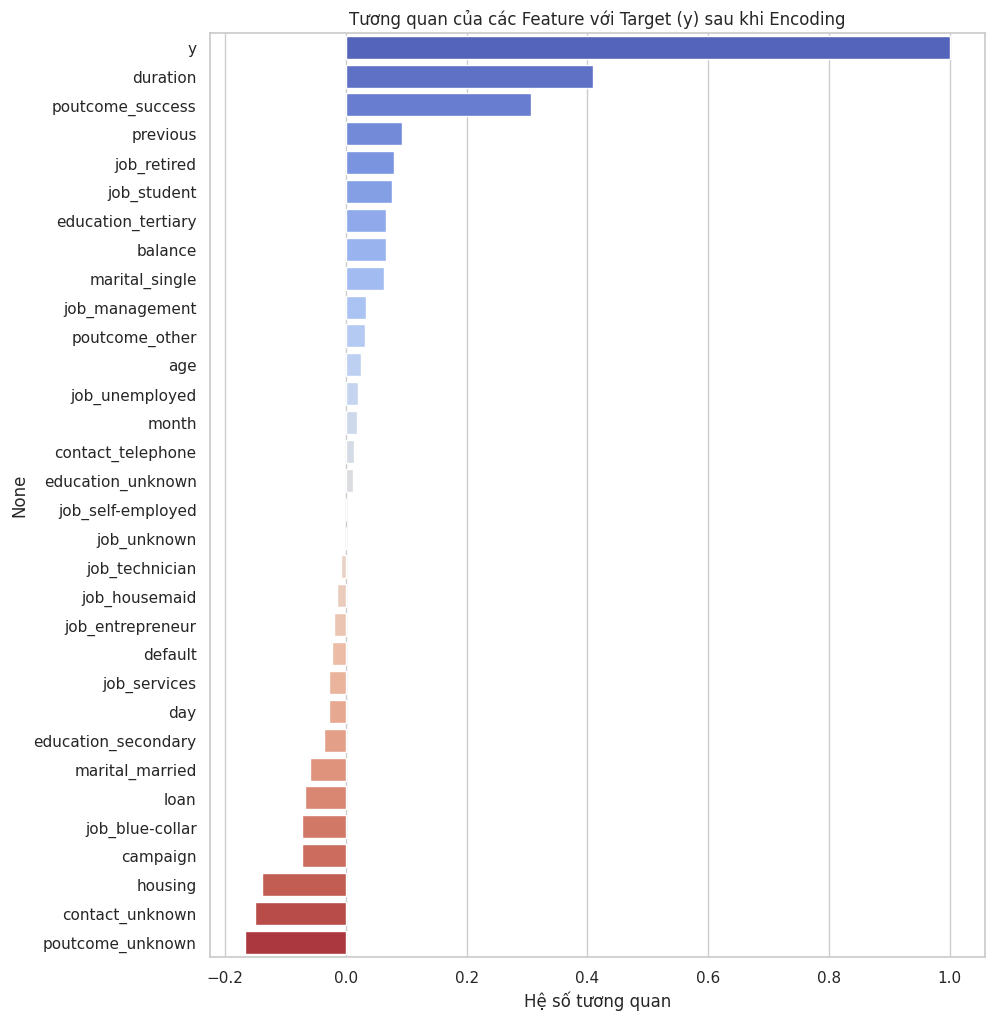

Dữ liệu hoàn toàn sạch, không có giá trị Null sau Encoding.


In [ ]:
# Kiểm tra tương quan của các feature mới với biến mục tiêu y
plt.figure(figsize=(10, 12))
corr_with_y = df_encoded.corr()['y'].sort_values(ascending=False)

sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')
plt.title('Tương quan của các Feature với Target (y) sau khi Encoding')
plt.xlabel('Hệ số tương quan')
plt.show()

# Kiểm tra giá trị Null phát sinh (nếu có)
if df_encoded.isnull().sum().sum() == 0:
    print("Dữ liệu hoàn toàn sạch, không có giá trị Null sau Encoding.")
else:
    print("Cảnh báo: Có giá trị Null phát sinh!")